# Amazon Reviews EDA — Smartphones (v3)
## Top-down funnel: Brand → Phone/Accessory → Model → Reviews

**Dataset:** UCSD Amazon Reviews 2023 (McAuley) — `Cell_Phones_and_Accessories.jsonl`

Rather than pre-specifying model patterns upfront, the pipeline uses a four-stage funnel.
Every inclusion decision is visible and auditable before any thesis event is locked in.

```
ALL METADATA
    │
    ▼  Stage 1 — Brand capture (broad keyword)
    ├─ Apple  : title contains 'iphone'
    ├─ Samsung: title contains 'galaxy s' + digit
    └─ Google : title contains 'pixel' + digit
         │
         ▼  Stage 2 — Phone / Accessory split
         ├─ Phone     : phone category AND no accessory keywords
         └─ Accessory : discarded, logged for audit
              │
              ▼  Stage 3 — Model classification + landscape visualisation
              ├─ iPhone 11-15, Pro, Mini, SE, XS/XR …
              ├─ Galaxy S10-S23, Ultra, Plus, FE …
              └─ Pixel 4-7, Pro, a, XL …
                   │
                   ▼  Stage 4 — Thesis event selection
                   └─ candidate_asins auto-populated → review loader → EDA
```


## Setup

In [16]:
import json, re
from collections import defaultdict, Counter
from datetime import timedelta
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from tqdm import tqdm

import re


In [2]:
# Palette 
LIGHT_BLUE   = '#8fd7d7';  MED_BLUE   = '#00b0be'
LIGHT_PINK   = '#ff8ca1';  MED_PINK   = '#f45f74'
LIGHT_GREEN  = '#bdd373';  MED_GREEN  = '#98c127'
LIGHT_ORANGE = '#ffcd8e';  MED_ORANGE = '#ffb255'
PALETTE = [MED_BLUE, MED_PINK, MED_GREEN, MED_ORANGE,
           LIGHT_BLUE, LIGHT_PINK, LIGHT_GREEN, LIGHT_ORANGE]

BRAND_COLOR = {'Apple': MED_PINK,    'Samsung': MED_ORANGE,  'Google': MED_GREEN, 'LG': MED_BLUE, 'Motorola': '#ff7f50', 'Huawei': '#9acd32'}
BRAND_LIGHT = {'Apple': LIGHT_PINK,  'Samsung': LIGHT_ORANGE,'Google': LIGHT_GREEN, 'LG': MED_BLUE, 'Motorola': '#ff7f50', 'Huawei': '#9acd32'}
TYPE_COLOR  = {'hedonic': MED_PINK,  'utilitarian': MED_BLUE}
TYPE_LIGHT  = {'hedonic': LIGHT_PINK,'utilitarian': LIGHT_BLUE}
TYPE_BG     = {'hedonic': '#fdf5f6', 'utilitarian': '#f0f8ff'}
TYPE_TITLE  = {'hedonic': '#7d1e2a', 'utilitarian': '#1a4a6b'}

plt.rcParams.update({
    'font.family':       'sans-serif',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.color':        '#eeeeee',
    'grid.linewidth':    0.8,
    'axes.facecolor':    '#fafafa',
    'figure.facecolor':  'white',
})
print('Palette loaded.')


Palette loaded.


In [3]:
BASE_DIR     = Path(r'C:\Users\User\Desktop\VU\Thesis\Code\LLM-prelaunch-buzz-postlaunch-predictor\Post-launch Amazon reviews')
META_FILE    = BASE_DIR / 'Meta'   / 'meta_Cell_Phones_and_Accessories.jsonl'
REVIEWS_FILE = BASE_DIR / 'Phones' / 'Cell_Phones_and_Accessories.jsonl'

for f in [META_FILE, REVIEWS_FILE]:
    ok   = f.exists()
    sym  = chr(10003) if ok else chr(10007)
    note = f'{f.stat().st_size/1e9:.2f} GB' if ok else 'NOT FOUND'
    print(f'{sym}  {f.name:<55} {note}')


✓  meta_Cell_Phones_and_Accessories.jsonl                  4.02 GB
✓  Cell_Phones_and_Accessories.jsonl                       9.34 GB


## Stage 1 — Brand-level capture

Scan every metadata record. Accept any record whose title matches a broad phone keyword.
No model specificity yet — pull everything in, sort downstream.

| Brand | Keyword used |
|---|---|
| Apple   | `iphone` |
| Samsung | `galaxy s` + digit (excludes Galaxy A/Z/Tab) |
| Google  | `pixel` + digit |


In [4]:
BRAND_RE = {
    'Apple':   re.compile(r'iphone',         re.IGNORECASE),
    'Samsung': re.compile(r'galaxy\s+s\d',  re.IGNORECASE),
    'Google':  re.compile(r'pixel\s+\d',     re.IGNORECASE),
    'LG': re.compile(r'\blg\s+(?:v\d|g\d|k\d|stylo|velvet|wing)\b', re.IGNORECASE),
    'Motorola': re.compile(r'moto(?:rola)?\s+(?:edge|g|z|razr|one|velvet)',  re.IGNORECASE),
    'Huawei':   re.compile(r'huawei\s+(?:p\d|mate|nova)|(?<!\w)honor\s+\d', re.IGNORECASE),
}

# brand -> {parent_asin: {title, categories, main_category}}
brand_hits = {b: {} for b in BRAND_RE}
n_read = 0

with open(META_FILE, 'r', encoding='utf-8') as f:
    for line in tqdm(f, desc='Stage 1 - brand scan', unit='rec'):
        line = line.strip()
        if not line:
            continue
        n_read += 1
        try:
            rec = json.loads(line)
        except json.JSONDecodeError:
            continue
        title = rec.get('title', '')
        if not title:
            continue
        for brand, pat in BRAND_RE.items():
            if pat.search(title):
                asin = rec.get('parent_asin', '')
                if asin and asin not in brand_hits[brand]:
                    brand_hits[brand][asin] = {
                        'title':         title,
                        'categories':    rec.get('categories', []),
                        'main_category': rec.get('main_category', ''),
                    }

print(f'Records read: {n_read:,}\n')
print(f'{"Brand":<10} {"ASINs":>10}')
print('-' * 22)
for brand, hits in brand_hits.items():
    print(f'{brand:<10} {len(hits):>10,}')


Stage 1 - brand scan: 1288490rec [01:53, 11381.33rec/s]

Records read: 1,288,490

Brand           ASINs
----------------------
Apple         424,395
Samsung       178,315
Google         22,449
LG             33,665
Motorola       38,180
Huawei          7,795


## Stage 2 — Phone / Accessory split

For each brand-matched ASIN decide: **phone** or **accessory**?

| Priority | Signal | Decision |
|---|---|---|
| 1 | Accessory keyword in title | Accessory |
| 2 | Category in phone whitelist | Phone |
| 3 | Neither (ambiguous) | Accessory (conservative) |

All rejected records are counted by reason so the decision boundary is fully inspectable.


In [5]:
PHONE_CATS = {
    'Cell Phones', 'Smartphones', 'Unlocked Cell Phones',
    'Prepaid Phones', 'No-Contract Phones',
}

ACCESSORY_CATS = {
    'Cases, Holsters & Sleeves',
    'Basic Cases',
    'Flip Cases',
    'Screen Protectors',
    'Holsters',
    'Replacement Parts',
    'Maintenance, Upkeep & Repairs',
    'Chargers & Power Adapters',
    'Cables & Adapters',
    'Wall Chargers',
    'Automobile Chargers',
    'Wireless Chargers',
    'Charging Stations',
    'Automobile Accessories',
    'Armbands',
    'Cradles',
    'Stylus Pens',
    'Batteries',
    'Dry Bags',
    'Photo & Video Accessories',
}

_ACCESSORY_PAT = (
    r'\b(case|cases|cover|covers'
    r'|screen\s*protector|tempered\s*glass|screen\s*guard'
    r'|charger|charging\s*cable|cable|adapter|dock|hub'
    r'|mount|holder|stand|armband|car\s*mount'
    r'|strap|band|skin|bumper|pouch|wallet|folio|flip|sleeve'
    r'|battery\s*pack|power\s*bank'
    r'|stylus|lens|grip|ring|kickstand|film|decal|sticker'
    r'|compatible\s+with)\b'   # removed: 'for iphone', 'for samsung', 'for pixel'
)
ACCESSORY_RE = re.compile(_ACCESSORY_PAT, re.IGNORECASE)

phone_asins     = {b: {} for b in BRAND_RE}
accessory_asins = {b: {} for b in BRAND_RE}
ambiguous_asins = {b: {} for b in BRAND_RE}   # new: kept separate for inspection
reject_reason   = Counter()

for brand, hits in brand_hits.items():
    for asin, info in hits.items():
        title = info['title']
        cats  = info['categories']
        is_accessory_kw   = bool(ACCESSORY_RE.search(title))
        has_accessory_cat = any(c in ACCESSORY_CATS for c in cats)
        has_phone_cat     = any(c in PHONE_CATS for c in cats)

        if is_accessory_kw or has_accessory_cat:
            accessory_asins[brand][asin] = title
            reject_reason['accessory keyword or category'] += 1
        elif has_phone_cat:
            phone_asins[brand][asin] = title
        else:
            # No phone category AND no accessory signal -- store separately
            ambiguous_asins[brand][asin] = title
            reject_reason['no phone category (ambiguous)'] += 1

print('STAGE 2 SUMMARY')
print('=' * 65)
print(f"{'Brand':<10} {'Total':>7} {'Phones':>8} {'Ambiguous':>10} {'Accessories':>12} {'Phone %':>8}")
print('-' * 60)
for brand in BRAND_RE:
    total = len(brand_hits[brand])
    ph    = len(phone_asins[brand])
    amb   = len(ambiguous_asins[brand])
    ac    = len(accessory_asins[brand])
    print(f'{brand:<10} {total:>7,} {ph:>8,} {amb:>10,} {ac:>12,}  {100*ph/max(total,1):>6.1f}%')

print()
print('Rejection reasons:')
for reason, n in reject_reason.most_common():
    print(f'  {n:>7,}  {reason}')

total_phones = sum(len(v) for v in phone_asins.values())
total_amb    = sum(len(v) for v in ambiguous_asins.values())
print(f'\nConfirmed phone ASINs : {total_phones:,}')
print(f'Ambiguous ASINs       : {total_amb:,}')


STAGE 2 SUMMARY
Brand        Total   Phones  Ambiguous  Accessories  Phone %
------------------------------------------------------------
Apple      424,395      169      5,018      419,208     0.0%
Samsung    178,315      308      1,363      176,644     0.2%
Google      22,449      115        153       22,181     0.5%
LG          33,665      126        351       33,188     0.4%
Motorola    38,180      347        302       37,531     0.9%
Huawei       7,795      148        233        7,414     1.9%

Rejection reasons:
  696,166  accessory keyword or category
    7,420  no phone category (ambiguous)

Confirmed phone ASINs : 1,213
Ambiguous ASINs       : 7,420


In [11]:
# Stage 2b Ambiguous ASIN inspection
# Sample ambiguous records per brand to decide: promote to phone, or discard?
N_SAMPLE = 15

print('AMBIGUOUS ASIN SAMPLE (no phone category, no accessory keyword)')
print('=' * 80)
print('Decision guide:')
print('  PHONE      → has a model number, storage size, colour, carrier info')
print('  ACCESSORY  → describes a product to use WITH a phone')
print('  JUNK       → clone, bundle, irrelevant product')
print()

for brand in BRAND_RE:
    amb = ambiguous_asins[brand]
    if not amb:
        continue
    print(f'{brand} ({len(amb):,} ambiguous ASINs) ')
    sample = list(amb.items())[:N_SAMPLE]
    for asin, title in sample:
        print(f'  {asin}  {title[:80]}')
    if len(amb) > N_SAMPLE:
        print(f'  ... and {len(amb)-N_SAMPLE:,} more')
    print()

# Category breakdown for ambiguous records 
print('CATEGORY STRINGS FOUND IN AMBIGUOUS RECORDS (top 20 per brand)')
print('=' * 80)
for brand in BRAND_RE:
    amb   = ambiguous_asins[brand]
    if not amb:
        continue
    cat_counter = Counter()
    for asin in amb:
        for cat in brand_hits[brand][asin]['categories']:
            cat_counter[cat] += 1
    print(f' {brand} ')
    for cat, n in cat_counter.most_common(20):
        print(f'  {n:>6,}  {cat}')
    print()

AMBIGUOUS ASIN SAMPLE (no phone category, no accessory keyword)
Decision guide:
  PHONE      → has a model number, storage size, colour, carrier info
  ACCESSORY  → describes a product to use WITH a phone
  JUNK       → clone, bundle, irrelevant product

CATEGORY STRINGS FOUND IN AMBIGUOUS RECORDS (top 20 per brand)


In [6]:
# ── Stage 2c — Promote validated ambiguous ASINs ──────────────────────────────

# Categories that unambiguously confirm a phone listing
PROMOTE_CATS_DIRECT = {
    'Wireless Trade-In Buy Box Widget',
    'Unlocked Wireless Trade-In',
    'Carrier Branded Wireless Trade-In',
    'Wireless Trade-In',
    'Android 101',
    'Verizon Wireless',
    'T-Mobile',
    'SIM Cards & Prepaid Minutes',
    'SIM Cards',
}

# 'Cell Phones & Accessories' is a mixed bag — apply a secondary title signal.
# A listing is a phone if the title contains:
#   - storage size (32GB / 64GB / 128GB / 256GB / 512GB)
#   - OR an explicit carrier / unlock mention
#   - OR a colour + model number pattern
PHONE_TITLE_RE = re.compile(
    r'\b(\d{2,3}\s*gb'                        # storage: 32GB, 128GB, 256GB
    r'|unlocked'                               # unlocked
    r'|factory\s+unlocked'
    r'|gsm\s+unlocked'
    r'|cdma'
    r'|at&t|verizon|t-mobile|sprint|cricket|boost|metro'   # carriers
    r'|renewed|refurbished|certified\s+refurbished'        # condition = product, not accessory
    r'|dual\s*sim'
    r'|single\s*sim)\b',
    re.IGNORECASE
)

# Categories to discard even if title looks phone-like
DISCARD_CATS = {
    'Accessories', 'iPhone Accessories', 'Virtual Reality (VR) Headsets',
    'Phone Charms', 'Décor', 'Gaming Accessories', 'Controllers', 'Triggers',
    'Grips', 'Smartwatch Accessories', 'Stands', 'Single Ear Bluetooth Headsets',
    'Signal Boosters',
    'Samsung Galaxy S5 Accessories', 'Samsung Galaxy S4 Store',
    'Samsung Galaxy S 7 Cases',
}

promoted   = Counter()
discarded  = Counter()
still_amb  = Counter()

for brand in BRAND_RE:
    for asin, title in list(ambiguous_asins[brand].items()):
        cats = set(brand_hits[brand][asin]['categories'])

        # Hard discard — accessory category overrides everything
        if cats & DISCARD_CATS:
            del ambiguous_asins[brand][asin]
            discarded[brand] += 1
            continue

        # Direct promote — unambiguous phone category
        if cats & PROMOTE_CATS_DIRECT:
            phone_asins[brand][asin] = title
            del ambiguous_asins[brand][asin]
            promoted[brand] += 1
            continue

        # Mixed category — apply title signal
        if 'Cell Phones & Accessories' in cats:
            if PHONE_TITLE_RE.search(title):
                phone_asins[brand][asin] = title
                del ambiguous_asins[brand][asin]
                promoted[brand] += 1
            else:
                # Cell Phones & Accessories but no phone signal in title → discard
                del ambiguous_asins[brand][asin]
                discarded[brand] += 1
            continue

        # Anything remaining — no category signal, no title signal → discard
        del ambiguous_asins[brand][asin]
        discarded[brand] += 1

# ── Summary ────────────────────────────────────────────────────────────────────
print(f"{'Brand':<12} {'Promoted':>10} {'Discarded':>10} {'Remaining':>10}")
print('-' * 45)
for brand in BRAND_RE:
    print(f"{brand:<12} {promoted[brand]:>10,} {discarded[brand]:>10,} "
          f"{len(ambiguous_asins[brand]):>10,}")

total_phones = sum(len(v) for v in phone_asins.values())
print(f'\nTotal confirmed phone ASINs after Stage 2c: {total_phones:,}')

# ── Spot-check: sample 20 promoted titles per brand ───────────────────────────
print('\nPROMOTED SAMPLE (20 per brand) — verify these look like phones:')
print('=' * 80)
for brand in BRAND_RE:
    new_phones = list(phone_asins[brand].items())
    print(f'\n── {brand} ──')
    for asin, title in new_phones[-20:]:   # last 20 = most recently added
        print(f'  {asin}  {title[:75]}')

Brand          Promoted  Discarded  Remaining
---------------------------------------------
Apple               747      4,271          0
Samsung             680        683          0
Google               93         60          0
LG                  209        142          0
Motorola            145        157          0
Huawei              146         87          0

Total confirmed phone ASINs after Stage 2c: 3,233

PROMOTED SAMPLE (20 per brand) — verify these look like phones:

── Apple ──
  B00SSDLULE  Apple iPhone 5C 8 GB Unlocked, Green
  B01LWZG707  Apple iPhone 7 Plus AT&T 128 GB (Silver) Locked to AT&T
  B0155VCZR4  Apple iPhone 6S 64GB Silver LTE Cellular Sprint MKTD2LL/A
  B00ICUSH4Q  Apple iPhone 5S 16 GB T-Mobile, Space Gray
  B01LY5U3EB  Apple iPhone 7 32GB Black Unlocked ATT Tmobile
  B01ELAWNOU  New Generic universal lost Remote Control suit for apple TV iPhone Mac Musi
  B00POQ3FP2  Apple iPhone 3G Black 8GB AT&T Factory Unlocked MB046LL/A
  B01LYUMNMY  Apple iPhone 7 1

In [7]:
# ── Stage 2c quick fixing: removing false positives from promoted set ───────────────────

# Remove SIM card categories from future promotions
PROMOTE_CATS_DIRECT -= {'SIM Cards & Prepaid Minutes', 'SIM Cards'}

# Secondary accessory pattern to catch SIM cutters / remote controls
# that slipped through the first filter
FALSE_POSITIVE_RE = re.compile(
    r'\b(sim\s*(card)?\s*(cutter|adapter|tray|slot|tool)'
    r'|nano\s*sim'
    r'|micro\s*sim'
    r'|prepaid\s*sim'
    r'|travel\s*sim'
    r'|remote\s*control'
    r'|replacement\s*(lcd|screen|digitizer|battery|button|cable|flex|lens|camera)'
    r'|repair\s*(kit|tool|part)'
    r'|screwdriver)\b',
    re.IGNORECASE
)

removed = Counter()
for brand in BRAND_RE:
    for asin, title in list(phone_asins[brand].items()):
        if FALSE_POSITIVE_RE.search(title):
            del phone_asins[brand][asin]
            removed[brand] += 1

print('False positives removed:')
for brand, n in removed.items():
    if n:
        print(f'  {brand:<12} {n:>4}')

total_phones = sum(len(v) for v in phone_asins.values())
print(f'\nFinal confirmed phone ASINs: {total_phones:,}')

False positives removed:
  Apple          49
  Samsung         6
  Google          1
  LG              1
  Motorola        1
  Huawei          2

Final confirmed phone ASINs: 3,173


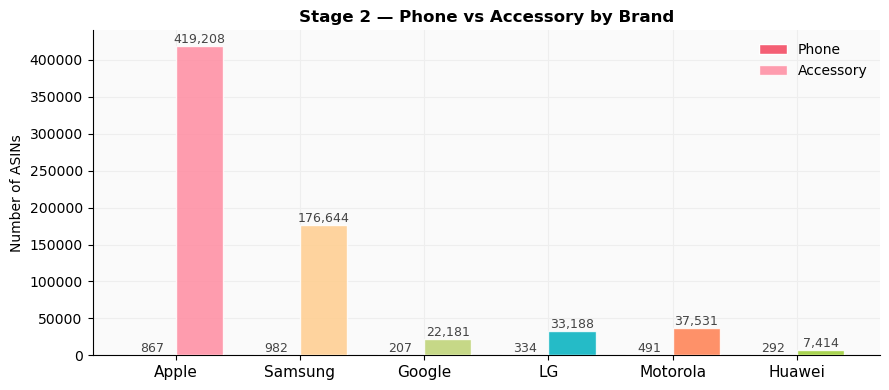

In [8]:
# Stage 2 — bar chart: phone vs accessory per brand
fig, ax = plt.subplots(figsize=(9, 4))
brands  = list(BRAND_RE.keys())
ph_cnt  = [len(phone_asins[b])     for b in brands]
ac_cnt  = [len(accessory_asins[b]) for b in brands]
x, w    = np.arange(len(brands)), 0.38
b1 = ax.bar(x-w/2, ph_cnt, width=w,
            color=[BRAND_COLOR[b] for b in brands],
            edgecolor='white', label='Phone', zorder=3)
b2 = ax.bar(x+w/2, ac_cnt, width=w,
            color=[BRAND_LIGHT[b] for b in brands],
            edgecolor='white', label='Accessory', zorder=3, alpha=0.85)
for bar, v in zip(list(b1)+list(b2), ph_cnt+ac_cnt):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            f'{v:,}', ha='center', va='bottom', fontsize=9, color='#444')
ax.set_xticks(x)
ax.set_xticklabels(brands, fontsize=11)
ax.set_ylabel('Number of ASINs')
ax.set_title('Stage 2 — Phone vs Accessory by Brand', fontweight='bold')
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig('stage2_split.png', dpi=150, bbox_inches='tight')
plt.show()


## Stage 3 — Model classification + landscape

Each confirmed phone ASIN is classified using **ordered regex classifiers** (most specific first).
All models are captured — not only pre-selected thesis candidates — so the landscape
visualisation shows the full distribution *before* any thesis-specific selection.

**Reading the landscape plot:**
- **Dark bars** = base models in thesis scope
- **Light bars** = variants (Pro, Ultra, Plus, Mini, FE) and catch-alls
- The distribution guides which events are viable based on ASIN count


In [12]:
def _c(p): return re.compile(p, re.IGNORECASE)

# Each list is ordered most-specific first. First match wins.
APPLE_CL = [
    ('iPhone 8 Plus',    _c(r'iphone\s*8\s+plus')),
    ('iPhone 8',         _c(r'iphone\s*8(?!\s*plus)')),
    ('iPhone 7 Plus',    _c(r'iphone\s*7\s+plus')),
    ('iPhone 7',         _c(r'iphone\s*7(?!\s*plus)')),
    ('iPhone 6S Plus',   _c(r'iphone\s*6s\s+plus')),
    ('iPhone 6S',        _c(r'iphone\s*6s(?!\s*plus)')),
    ('iPhone 6 Plus',    _c(r'iphone\s*6\s+plus')),
    ('iPhone 6',         _c(r'iphone\s*6(?!\s*(s|plus))')),
    ('iPhone 5S',        _c(r'iphone\s*5s')),
    ('iPhone 5C',        _c(r'iphone\s*5c')),
    ('iPhone 5',         _c(r'iphone\s*5(?!\s*(s|c))')),
    ('iPhone 4S',        _c(r'iphone\s*4s')),
    ('iPhone 4',         _c(r'iphone\s*4(?!\s*s)')),
    ('iPhone 15 Pro Max', _c(r'iphone\s*15\s+pro\s+max')),
    ('iPhone 15 Pro',     _c(r'iphone\s*15\s+pro(?!\s+max)')),
    ('iPhone 15 Plus',    _c(r'iphone\s*15\s+plus')),
    ('iPhone 15',         _c(r'iphone\s*15(?!\s*(pro|plus|max))')),
    ('iPhone 14 Pro Max', _c(r'iphone\s*14\s+pro\s+max')),
    ('iPhone 14 Pro',     _c(r'iphone\s*14\s+pro(?!\s+max)')),
    ('iPhone 14 Plus',    _c(r'iphone\s*14\s+plus')),
    ('iPhone 14',         _c(r'iphone\s*14(?!\s*(pro|plus|max))')),
    ('iPhone 13 Pro Max', _c(r'iphone\s*13\s+pro\s+max')),
    ('iPhone 13 Pro',     _c(r'iphone\s*13\s+pro(?!\s+max)')),
    ('iPhone 13 Mini',    _c(r'iphone\s*13\s+mini')),
    ('iPhone 13',         _c(r'iphone\s*13(?!\s*(pro|mini|max))')),
    ('iPhone 12 Pro Max', _c(r'iphone\s*12\s+pro\s+max')),
    ('iPhone 12 Pro',     _c(r'iphone\s*12\s+pro(?!\s+max)')),
    ('iPhone 12 Mini',    _c(r'iphone\s*12\s+mini')),
    ('iPhone 12',         _c(r'iphone\s*12(?!\s*(pro|mini|max))')),
    ('iPhone 11 Pro Max', _c(r'iphone\s*11\s+pro\s+max')),
    ('iPhone 11 Pro',     _c(r'iphone\s*11\s+pro(?!\s+max)')),
    ('iPhone 11',         _c(r'iphone\s*11(?!\s*(pro|max))')),
    ('iPhone SE 3rd Gen', _c(r'iphone\s*se.{0,10}(3rd|2022)')),
    ('iPhone SE 2nd Gen', _c(r'iphone\s*se.{0,10}(2nd|2020)')),
    ('iPhone SE',         _c(r'iphone\s*se')),
    ('iPhone XS Max',     _c(r'iphone\s*xs\s+max')),
    ('iPhone XS',         _c(r'iphone\s*xs(?!\s+max)')),
    ('iPhone XR',         _c(r'iphone\s*xr')),
    ('iPhone X',          _c(r'iphone\s*x(?!\s*(?:s\b|r\b|max\b|\d))')),
    ('iPhone 3GS',        _c(r'iphone\s*3gs')),
    ('iPhone 3G',         _c(r'iphone\s*3g(?!s)')),
    ('iPhone 2G',         _c(r'iphone\s*(?:2g|1st\s*gen|original)')),
    ('iPhone Other',      _c(r'iphone')),
]

SAMSUNG_CL = [
    ('Galaxy S10 5G',    _c(r'galaxy\s+s10\s+5g')),
    ('Galaxy S9+',       _c(r'galaxy\s+s9\s*(plus|\+)')),
    ('Galaxy S9',        _c(r'galaxy\s+s9(?!\s*(plus|\+))')),
    ('Galaxy S8+',       _c(r'galaxy\s+s8\s*(plus|\+)')),
    ('Galaxy S8',        _c(r'galaxy\s+s8(?!\s*(plus|\+))')),
    ('Galaxy S7 Edge',   _c(r'galaxy\s+s7\s+edge')),
    ('Galaxy S7',        _c(r'galaxy\s+s7(?!\s*edge)')),
    ('Galaxy S6 Edge+',  _c(r'galaxy\s+s6\s+edge\s*(plus|\+)')),
    ('Galaxy S6 Edge',   _c(r'galaxy\s+s6\s+edge(?!\s*(plus|\+))')),
    ('Galaxy S6',        _c(r'galaxy\s+s6(?!\s*edge)')),
    ('Galaxy S5',        _c(r'galaxy\s+s5')),
    ('Galaxy S4',        _c(r'galaxy\s+s4')),
    ('Galaxy S3',        _c(r'galaxy\s+s3')),
    ('Galaxy S23 Ultra',  _c(r'galaxy\s+s23\s+ultra')),
    ('Galaxy S23+',       _c(r'galaxy\s+s23\s*(plus|\+)(?!\s*ultra)')),
    ('Galaxy S23 FE',     _c(r'galaxy\s+s23\s+fe')),
    ('Galaxy S23',        _c(r'galaxy\s+s23(?!\s*(ultra|plus|\+|fe))')),
    ('Galaxy S22 Ultra',  _c(r'galaxy\s+s22\s+ultra')),
    ('Galaxy S22+',       _c(r'galaxy\s+s22\s*(plus|\+)(?!\s*ultra)')),
    ('Galaxy S22',        _c(r'galaxy\s+s22(?!\s*(ultra|plus|\+))')),
    ('Galaxy S21 Ultra',  _c(r'galaxy\s+s21\s+ultra')),
    ('Galaxy S21+',       _c(r'galaxy\s+s21\s*(plus|\+)(?!\s*ultra)')),
    ('Galaxy S21 FE',     _c(r'galaxy\s+s21\s+fe')),
    ('Galaxy S21',        _c(r'galaxy\s+s21(?!\s*(ultra|plus|\+|fe))')),
    ('Galaxy S20 Ultra',  _c(r'galaxy\s+s20\s+ultra')),
    ('Galaxy S20+',       _c(r'galaxy\s+s20\s*(plus|\+)(?!\s*ultra)')),
    ('Galaxy S20 FE',     _c(r'galaxy\s+s20\s+fe')),
    ('Galaxy S20',        _c(r'galaxy\s+s20(?!\s*(ultra|plus|\+|fe))')),
    ('Galaxy S10+',       _c(r'galaxy\s+s10\s*(plus|\+)')),
    ('Galaxy S10e',       _c(r'galaxy\s+s10e')),
    ('Galaxy S10',        _c(r'galaxy\s+s10(?!\s*(plus|\+|e|5g))')),
    ('Galaxy S2 Skyrocket',_c(r'galaxy\s+s2\s+skyrocket')),
    ('Galaxy S2',          _c(r'galaxy\s+s2(?!\s*skyrocket)')),
    ('Galaxy S Other',    _c(r'galaxy\s+s\d')),
    # J-series (high Amazon volume, mid-range)
    ('Galaxy J7 Crown',  _c(r'galaxy\s+j7\s+crown')),
    ('Galaxy J7 Refine', _c(r'galaxy\s+j7\s+refine')),
    ('Galaxy J7',        _c(r'galaxy\s+j7(?!\s*(crown|refine|prime|duo|sky|perx))')),
    ('Galaxy J3',        _c(r'galaxy\s+j3')),
    ('Galaxy J Other',   _c(r'galaxy\s+j\d')),
    # A-series
    ('Galaxy A53',       _c(r'galaxy\s+a53')),
    ('Galaxy A52',       _c(r'galaxy\s+a52')),
    ('Galaxy A51',       _c(r'galaxy\s+a51')),
    ('Galaxy A32',       _c(r'galaxy\s+a32')),
    ('Galaxy A21',       _c(r'galaxy\s+a21')),
    ('Galaxy A12',       _c(r'galaxy\s+a12')),
    ('Galaxy A11',       _c(r'galaxy\s+a11')),
    ('Galaxy A10',       _c(r'galaxy\s+a10')),
    ('Galaxy A Other',   _c(r'galaxy\s+a\d')),
]

PIXEL_CL = [
    ('Pixel 7 Pro',  _c(r'pixel\s+7\s+pro')),
    ('Pixel 7',      _c(r'pixel\s+7(?!\s*(pro|a|xl))')),
    ('Pixel 6 Pro',  _c(r'pixel\s+6\s+pro')),
    ('Pixel 6a',     _c(r'pixel\s+6a')),
    ('Pixel 6',      _c(r'pixel\s+6(?!\s*(pro|a))')),
    ('Pixel 5a',     _c(r'pixel\s+5a')),
    ('Pixel 5',      _c(r'pixel\s+5(?!\s*a)')),
    ('Pixel 4a 5G',  _c(r'pixel\s+4a\s+5g')),
    ('Pixel 4a',     _c(r'pixel\s+4a(?!\s+5g)')),
    ('Pixel 4 XL',   _c(r'pixel\s+4\s+xl')),
    ('Pixel 4',      _c(r'pixel\s+4(?!\s*(a|xl))')),
    ('Pixel 3a XL',  _c(r'pixel\s+3a\s+xl')),
    ('Pixel 3a',     _c(r'pixel\s+3a(?!\s+xl)')),
    ('Pixel 3 XL',   _c(r'pixel\s+3\s+xl')),
    ('Pixel 3',      _c(r'pixel\s+3(?!\s*(a|xl))')),
    ('Pixel 2 XL',   _c(r'pixel\s+2\s+xl')),
    ('Pixel 2',      _c(r'pixel\s+2(?!\s*xl)')),
    ('Pixel 1',      _c(r'pixel\s+(?:32gb|64gb|128gb)'           )),
    ('Pixel 3 XL',   _c(r'pixel\s+3\s*xl'                        )),  # catch "3XL" (no space)
    ('Pixel 3XL',    _c(r'pixel\s+3xl'                           )),
    ('Pixel Other',  _c(r'pixel\s+\d')),
]

# LG
# Note: LG exited smartphones April 2021 â€” no new models after LG Wing / Velvet.
# V-series and G-series are the flagship lines; Stylo/K are mid-range.
LG_CL = [
    # Velvet & Wing (last flagships)
    ('LG Velvet 5G',     _c(r'lg\s+velvet\s+5g')),
    ('LG Velvet',        _c(r'lg\s+velvet(?!\s+5g)')),
    ('LG Wing',          _c(r'lg\s+wing')),
    # V-series
    ('LG V60 ThinQ',     _c(r'lg\s+v60')),
    ('LG V50 ThinQ',     _c(r'lg\s+v50')),
    ('LG V40 ThinQ',     _c(r'lg\s+v40')),
    ('LG V35 ThinQ',     _c(r'lg\s+v35')),
    ('LG V30',           _c(r'lg\s+v30')),
    # G-series
    ('LG G2 Mini',        _c(r'lg\s+g2\s+mini')),
    ('LG G2',             _c(r'lg\s+g2(?!\s*mini)')),
    ('LG G5',        _c(r'lg\s+g5')),
    ('LG G4',        _c(r'lg\s+g4')),
    ('LG G3',        _c(r'lg\s+g3')),
    ('LG G8X ThinQ',     _c(r'lg\s+g8x')),
    ('LG G8S ThinQ',     _c(r'lg\s+g8s')),
    ('LG G8 ThinQ',      _c(r'lg\s+g8(?!\s*(x|s))')),
    ('LG G7 ThinQ',      _c(r'lg\s+g7')),
    ('LG G6',            _c(r'lg\s+g6')),
    # Stylo series (mid-range)
    ('LG Stylo 3 Plus',    _c(r'lg\s+stylo\s*3\s+plus')),
    ('LG Stylo 3',         _c(r'lg\s+stylo\s*3(?!\s*plus)')),
    ('LG Stylo 2',         _c(r'lg\s+stylo\s*2')),
    ('LG Stylo 6',       _c(r'lg\s+stylo\s*6')),
    ('LG Stylo 5',       _c(r'lg\s+stylo\s*5')),
    ('LG Stylo 4',       _c(r'lg\s+stylo\s*4')),
    ('LG Stylo Other',   _c(r'lg\s+stylo')),
    # K-series
    ('LG K10',       _c(r'lg\s+k10')),
    ('LG K20',       _c(r'lg\s+k20')),
    ('LG K30',       _c(r'lg\s+k30')),
    ('LG K40',       _c(r'lg\s+k40')),
    ('LG K92',           _c(r'lg\s+k92')),
    ('LG K71',           _c(r'lg\s+k71')),
    ('LG K51',           _c(r'lg\s+k51')),
    ('LG K42',           _c(r'lg\s+k42')),
    ('LG K8',              _c(r'lg\s+k8')),
    ('LG K7',              _c(r'lg\s+k7')),
    ('LG K9',              _c(r'lg\s+k9')),
    ('LG K5',              _c(r'lg\s+k5')),
    ('LG K4',              _c(r'lg\s+k4')),
    ('LG K3',              _c(r'lg\s+k3')),
    ('LG K Series Other',_c(r'lg\s+k\d')),
    # catch-all
    ('LG Other',         _c(r'\blg\b')),
]

# Motorola 
# Edge series = premium; G series = mid-range (very high Amazon volume);
# Razr = foldable. Year suffixes are common: "(2022)", "2022", "2023".
MOTOROLA_CL = [
    # Edge 40 family
    ('Moto Edge 40 Pro',    _c(r'(?:moto(?:rola)?)\s+edge\s+40\s+pro')),
    ('Moto Edge 40 Neo',    _c(r'(?:moto(?:rola)?)\s+edge\s+40\s+neo')),
    ('Moto Edge 40',        _c(r'(?:moto(?:rola)?)\s+edge\s+40(?!\s*(pro|neo|ultra|\+))')),
    # Edge 30 family
    ('Moto Edge 30 Ultra',  _c(r'(?:moto(?:rola)?)\s+edge\s+30\s+ultra')),
    ('Moto Edge 30 Pro',    _c(r'(?:moto(?:rola)?)\s+edge\s+30\s+pro')),
    ('Moto Edge 30 Fusion', _c(r'(?:moto(?:rola)?)\s+edge\s+30\s+fusion')),
    ('Moto Edge 30 Neo',    _c(r'(?:moto(?:rola)?)\s+edge\s+30\s+neo')),
    ('Moto Edge 30',        _c(r'(?:moto(?:rola)?)\s+edge\s+30(?!\s*(ultra|pro|fusion|neo|\+))')),
    # Edge 20 family
    ('Moto Edge 20 Pro',    _c(r'(?:moto(?:rola)?)\s+edge\s+20\s+pro')),
    ('Moto Edge 20 Fusion', _c(r'(?:moto(?:rola)?)\s+edge\s+20\s+fusion')),
    ('Moto Edge 20 Lite',   _c(r'(?:moto(?:rola)?)\s+edge\s+20\s+lite')),
    ('Moto Edge 20',        _c(r'(?:moto(?:rola)?)\s+edge\s+20(?!\s*(pro|fusion|lite|\+))')),
    # Edge (original) / Edge+
    ('Moto Edge+',          _c(r'(?:moto(?:rola)?)\s+edge\s*(?:plus|\+)(?!\s*\d)')),
    ('Moto Edge',           _c(r'(?:moto(?:rola)?)\s+edge(?!\s*(?:plus|\+|\d))')),
    # Razr
    ('Motorola Razr 2023',  _c(r'(?:moto(?:rola)?)\s+razr.{0,10}(2023|40)')),
    ('Motorola Razr 2022',  _c(r'(?:moto(?:rola)?)\s+razr.{0,10}(2022)')),
    ('Motorola Razr 2019',  _c(r'(?:moto(?:rola)?)\s+razr.{0,10}(2019)')),
    ('Motorola Razr Other', _c(r'(?:moto(?:rola)?)\s+razr')),
    ('Motorola Razr V3xx', _c(r'razr\s+v3xx')),
    ('Motorola Razr V3m',  _c(r'razr\s+v3m')),
    ('Motorola Razr V3i',  _c(r'razr\s+v3i')),
    ('Motorola Razr V3t',  _c(r'razr\s+v3t')),
    ('Motorola Razr V3',   _c(r'razr\s+v3(?!x|m|i|t)')),
    ('Motorola Razr2 V9',  _c(r'razr2?\s+v9')),
    ('Motorola Razr 5G',   _c(r'razr\s+5g')),
    ('Motorola Razr 2020', _c(r'razr.{0,10}2020')),
    # Moto G Stylus year variants (must come before plain G Stylus)
    ('Moto G Stylus 5G 2023', _c(r'moto\s+g\s+stylus\s+5g.{0,6}2023')),
    ('Moto G Stylus 5G 2022', _c(r'moto\s+g\s+stylus\s+5g.{0,6}2022')),
    ('Moto G Stylus 5G 2021', _c(r'moto\s+g\s+stylus\s+5g.{0,6}2021')),
    ('Moto G Stylus 5G',      _c(r'moto\s+g\s+stylus\s+5g')),
    ('Moto G Stylus 2022',    _c(r'moto\s+g\s+stylus.{0,6}2022')),
    ('Moto G Stylus 2021',    _c(r'moto\s+g\s+stylus.{0,6}2021')),
    ('Moto G Stylus',         _c(r'moto\s+g\s+stylus')),
    # Moto G Power  year variants
    ('Moto G Power 5G 2023',  _c(r'moto\s+g\s+power\s+5g.{0,6}2023')),
    ('Moto G Power 2023',     _c(r'moto\s+g\s+power.{0,6}2023')),
    ('Moto G Power 2022',     _c(r'moto\s+g\s+power.{0,6}2022')),
    ('Moto G Power 2021',     _c(r'moto\s+g\s+power.{0,6}2021')),
    ('Moto G Power',          _c(r'moto\s+g\s+power')),
    # Moto G Play  year variants
    ('Moto G Play 2023',      _c(r'moto\s+g\s+play.{0,6}2023')),
    ('Moto G Play 2022',      _c(r'moto\s+g\s+play.{0,6}2022')),
    ('Moto G Play 2021',      _c(r'moto\s+g\s+play.{0,6}2021')),
    ('Moto G Play',           _c(r'moto\s+g\s+play')),
    # Moto G Pure / Fast / 5G
    ('Moto G Pure',           _c(r'moto\s+g\s+pure')),
    ('Moto G Fast',           _c(r'moto\s+g\s+fast')),
    ('Moto G 5G Plus',        _c(r'moto\s+g\s+5g\s+plus')),
    ('Moto G 5G',             _c(r'moto\s+g\s+5g(?!\s+plus)')),
    # Moto G numbered (G10/G20/G30/G50/G60/G71/G82/G200)
    ('Moto G9 Plus',      _c(r'moto(?:rola)?\s+g9\s+plus')),
    ('Moto G9 Play',      _c(r'moto(?:rola)?\s+g9\s+play')),
    ('Moto G9',           _c(r'moto(?:rola)?\s+g9(?!\s*(plus|play))')),
    ('Moto G8 Power',     _c(r'moto(?:rola)?\s+g8\s+power')),
    ('Moto G8 Play',      _c(r'moto(?:rola)?\s+g8\s+play')),
    ('Moto G8',           _c(r'moto(?:rola)?\s+g8(?!\s*(power|play|plus))')),
    ('Moto G5S Plus',     _c(r'moto(?:rola)?\s+g5s\s+plus')),
    ('Moto G5S',          _c(r'moto(?:rola)?\s+g5s(?!\s*plus)')),
    ('Moto G5 Plus',      _c(r'moto(?:rola)?\s+g5\s+plus')),
    ('Moto G5',           _c(r'moto(?:rola)?\s+g5(?!\s*(plus|s))')),
    ('Moto G4 Plus',      _c(r'moto(?:rola)?\s+g4\s+plus')),
    ('Moto G4 Play',      _c(r'moto(?:rola)?\s+g4\s+play')),
    ('Moto G4',           _c(r'moto(?:rola)?\s+g4(?!\s*(plus|play))')),
    ('Moto G3',           _c(r'moto(?:rola)?\s+g3')),
    ('Moto G 4th Gen',    _c(r'moto\s+g\s+\(?4th')),
    ('Moto G 5th Gen',    _c(r'moto\s+g\s+\(?5th')),
    ('Moto G 3rd Gen',    _c(r'moto\s+g\s+\(?3rd')),
    ('Moto G200',             _c(r'moto\s+g\s*200')),
    ('Moto G82',              _c(r'moto\s+g\s*82')),
    ('Moto G71',              _c(r'moto\s+g\s*71')),
    ('Moto G60',              _c(r'moto\s+g\s*60')),
    ('Moto G50',              _c(r'moto\s+g\s*50')),
    ('Moto G30',              _c(r'moto\s+g\s*30')),
    ('Moto G20',              _c(r'moto\s+g\s*20')),
    ('Moto G10',              _c(r'moto\s+g\s*10')),
    ('Moto G53',          _c(r'moto(?:rola)?\s+g\s*53')),
    ('Moto G62',          _c(r'moto(?:rola)?\s+g\s*62')),
    ('Moto G51',          _c(r'moto(?:rola)?\s+g\s*51')),
    ('Moto G32',          _c(r'moto(?:rola)?\s+g\s*32')),
    ('Moto G22',          _c(r'moto(?:rola)?\s+g\s*22')),
    # Moto G catch-all
    ('Moto G Other',          _c(r'moto\s+g')),
    # Moto Z
    ('Moto Z4',               _c(r'moto\s+z4')),
    ('Moto Z3',               _c(r'moto\s+z3')),
    ('Moto Z2',               _c(r'moto\s+z2')),
    ('Moto Z Play',       _c(r'moto(?:rola)?\s+z\s+play')),
    ('Moto Z Force',      _c(r'moto(?:rola)?\s+z\s+(?:force|droid\s+force)')),
    ('Moto Z Droid',      _c(r'moto(?:rola)?\s+z\s+droid(?!\s+force)')),
    ('Moto Z3 Play',      _c(r'moto(?:rola)?\s+z3\s+play')),
    ('Moto Z2 Play',      _c(r'moto(?:rola)?\s+z2\s+play')),
    ('Moto Z2 Force',     _c(r'moto(?:rola)?\s+z2\s+force')),
    ('Moto Z Other',          _c(r'moto\s+z')),
    # One series
    ('Motorola One 5G Ace',   _c(r'(?:moto(?:rola)?)\s+one\s+5g\s+ace')),
    ('Motorola One 5G',       _c(r'(?:moto(?:rola)?)\s+one\s+5g(?!\s+ace)')),
    ('Motorola One Action',   _c(r'(?:moto(?:rola)?)\s+one\s+action')),
    ('Motorola One Vision',   _c(r'(?:moto(?:rola)?)\s+one\s+vision')),
    ('Motorola One Other',    _c(r'(?:moto(?:rola)?)\s+one')),
    # G7 family
    ('Moto G7 Power',  _c(r'moto\s+g7\s+power')),
    ('Moto G7 Plus',   _c(r'moto\s+g7\s+plus')),
    ('Moto G7 Play',   _c(r'moto\s+g7\s+play')),
    ('Moto G7',        _c(r'moto\s+g7(?!\s*(power|plus|play))')),
    # G6 family
    ('Moto G6 Plus',   _c(r'moto\s+g6\s+plus')),
    ('Moto G6 Play',   _c(r'moto\s+g6\s+play')),
    ('Moto G6',        _c(r'moto\s+g6(?!\s*(plus|play))')),
    # E-series (budget, high Amazon volume)
    ('Moto E6 Plus',   _c(r'moto\s+e6\s+plus')),
    ('Moto E6',        _c(r'moto\s+e6(?!\s*plus)')),
    ('Moto E5 Plus',   _c(r'moto\s+e5\s+plus')),
    ('Moto E5 Play',   _c(r'moto\s+e5\s+play')),
    ('Moto E5',        _c(r'moto\s+e5(?!\s*(plus|play))')),
    ('Moto E4 Plus',   _c(r'moto\s+e4\s+plus')),
    ('Moto E4',        _c(r'moto\s+e4(?!\s*plus)')),
    ('Moto Edge 5G UW',   _c(r'(?:moto(?:rola)?)\s+edge\s+5g\s+uw')),
    ('Motorola Nexus 6',  _c(r'(?:motorola|nexus)\s+(?:google\s+)?nexus\s+6')),

    ('Moto E Other',   _c(r'moto\s+e\d')),
    # catch-all
    ('Motorola Other',        _c(r'motoro?l?a?')),
]

# Huawei 
# US sanctions (May 2019) severely curtailed Amazon availability post-P30.
# P-series and Mate-series are flagship lines; Nova is mid-range.
# Honor was a sub-brand until 2020 spinoff included here with a note.
HUAWEI_CL = [
    # P60 family (2023 US availability limited to P60 Pro via third-party sellers)
    ('Huawei P60 Pro',     _c(r'huawei\s+p60\s+pro')),
    ('Huawei P60',         _c(r'huawei\s+p60(?!\s*pro)')),
    # P50 family (2021 very limited US availability post-sanctions)
    ('Huawei P50 Pro',      _c(r'huawei\s+p50\s+pro')),
    ('Huawei P50',          _c(r'huawei\s+p50(?!\s*pro)')),
    # P40 family
    ('Huawei P40 Pro+',     _c(r'huawei\s+p40\s+pro\s*(?:plus|\+)')),
    ('Huawei P40 Pro',      _c(r'huawei\s+p40\s+pro(?!\s*(?:plus|\+))')),
    ('Huawei P40 Lite',     _c(r'huawei\s+p40\s+lite')),
    ('Huawei P40',          _c(r'huawei\s+p40(?!\s*(pro|lite))')),
    # P30 family (last widely available on Amazon before sanctions fully hit)
    ('Huawei P30 Pro',      _c(r'huawei\s+p30\s+pro')),
    ('Huawei P30 Lite',     _c(r'huawei\s+p30\s+lite')),
    ('Huawei P30',          _c(r'huawei\s+p30(?!\s*(pro|lite))')),
    # P20 family
    ('Huawei P20 Pro',      _c(r'huawei\s+p20\s+pro')),
    ('Huawei P20 Lite',     _c(r'huawei\s+p20\s+lite')),
    ('Huawei P20',          _c(r'huawei\s+p20(?!\s*(pro|lite))')),
    # P10 family
    ('Huawei P10 Plus',    _c(r'huawei\s+p10\s+(?:plus|\+)')),
    ('Huawei P10 Lite',    _c(r'huawei\s+p10\s+lite')),
    ('Huawei P10 Selfie',  _c(r'huawei\s+p10\s+selfie')),
    ('Huawei P10',         _c(r'huawei\s+p10(?!\s*(plus|\+|lite|selfie))')),

    # P9 Family (2016-17 models, some Amazon availability in early 2020s)
    ('Huawei P9 Plus',     _c(r'huawei\s+p9\s+(?:plus|\+)')),
    ('Huawei P9 Lite',     _c(r'huawei\s+p9\s+lite')),
    ('Huawei P9',          _c(r'huawei\s+p9(?!\s*(plus|\+|lite))')),
    # P8 Family (2015-16 models, some Amazon availability in early 2020s)
    ('Huawei P8 Lite',     _c(r'huawei\s+p8\s+lite')),
    ('Huawei P8',          _c(r'huawei\s+p8(?!\s*lite)')),
    # Mate 40 family
    ('Huawei Mate 40 Pro',  _c(r'huawei\s+mate\s+40\s+pro')),
    ('Huawei Mate 40',      _c(r'huawei\s+mate\s+40(?!\s*pro)')),
    # Mate 30 family
    ('Huawei Mate 30 Pro',  _c(r'huawei\s+mate\s+30\s+pro')),
    ('Huawei Mate 30',      _c(r'huawei\s+mate\s+30(?!\s*pro)')),
    # Mate 20 family
    ('Huawei Mate 20 Pro',  _c(r'huawei\s+mate\s+20\s+pro')),
    ('Huawei Mate 20 X',    _c(r'huawei\s+mate\s+20\s+x')),
    ('Huawei Mate 20 Lite', _c(r'huawei\s+mate\s+20\s+lite')),
    ('Huawei Mate 20',      _c(r'huawei\s+mate\s+20(?!\s*(pro|x|lite))')),
    ('Huawei Mate 10 Pro', _c(r'huawei\s+mate\s+10\s+pro')),
    ('Huawei Mate 10',     _c(r'huawei\s+mate\s+10(?!\s*pro)')),
    ('Huawei Mate SE',     _c(r'huawei\s+mate\s+se')),
    ('Huawei Mate 9 Pro',  _c(r'huawei\s+mate\s+9\s+pro')),
    ('Huawei Mate 9 Lite', _c(r'huawei\s+mate\s+9\s+lite')),
    ('Huawei Mate 9',      _c(r'huawei\s+mate\s+9(?!\s*(pro|lite))')),
    ('Huawei Mate 8',      _c(r'huawei\s+mate\s+8')),
    ('Huawei Mate RS',     _c(r'huawei\s+(?:porsche\s+design\s+)?mate\s+rs')),

    # Nova series (mid-range)
    ('Huawei Nova 9',       _c(r'huawei\s+nova\s*9')),
    ('Huawei Nova 8',       _c(r'huawei\s+nova\s*8')),
    ('Huawei Nova 7',       _c(r'huawei\s+nova\s*7')),
    ('Huawei Nova Other',   _c(r'huawei\s+nova')),
    ('Huawei Nova 5T',     _c(r'(?:huawei\s+)?nova\s+5t')),
    ('Huawei Nova 4e',     _c(r'(?:huawei\s+)?nova\s+4e')),
    ('Huawei Nova 3i',     _c(r'(?:huawei\s+)?nova\s+3i')),
    ('Huawei Nova 3',      _c(r'(?:huawei\s+)?nova\s+3(?!i)')),
    # Honor (sub-brand; listed here since many UCSD records predate 2020 spinoff)
    ('Honor 50',            _c(r'honor\s+50')),
    ('Honor 30',            _c(r'honor\s+30')),
    ('Honor 20',            _c(r'honor\s+20')),
    ('Honor View 20',       _c(r'honor\s+view\s+20')),
    ('Honor 10',            _c(r'honor\s+10')),
    ('Honor Other',         _c(r'\bhonor\b')),
    ('Honor 8X Max',       _c(r'honor\s+8x\s+max')),
    ('Honor 8X',           _c(r'honor\s+8x(?!\s*max)')),
    ('Honor 8A',           _c(r'honor\s+8a')),
    ('Honor 8S',           _c(r'honor\s+8s')),
    ('Honor 8',            _c(r'honor\s+8(?!\s*(x|a|s))')),
    ('Honor 9X Pro',       _c(r'honor\s+9x\s+pro')),
    ('Honor 9X',           _c(r'honor\s+9x(?!\s*pro)')),
    ('Honor 9',            _c(r'honor\s+9(?!\s*x)')),
    ('Honor 7X',           _c(r'honor\s+7x')),
    ('Honor 7C',           _c(r'honor\s+7c')),
    ('Honor 7A',           _c(r'honor\s+7a')),
    ('Honor 7S',           _c(r'honor\s+7s')),
    ('Honor 6X',           _c(r'honor\s+6x')),
    ('Honor 6',            _c(r'honor\s+6(?!\s*x)')),
    ('Honor 5X',           _c(r'honor\s+5x')),
    ('Honor 5A',           _c(r'honor\s+5a')),
    ('Honor 4',            _c(r'honor\s+4')),
    ('Honor 3C',           _c(r'honor\s+3c')),
    ('Honor 3',            _c(r'honor\s+3(?!c)')),
    # catch-all
    ('Huawei Other',        _c(r'huawei')),
]

ALL_CL = {'Apple': APPLE_CL, 'Samsung': SAMSUNG_CL, 'Google': PIXEL_CL, 'LG': LG_CL, 'Motorola': MOTOROLA_CL, 'Huawei': HUAWEI_CL}

def classify_model(title, classifiers):
    for model_key, pat in classifiers:
        if pat.search(title):
            return model_key
    return 'Unclassified'

model_asins = defaultdict(dict)   # model_key -> {parent_asin: title}
model_brand = {}                   # model_key -> brand

for brand, cl in ALL_CL.items():
    for asin, title in phone_asins[brand].items():
        key = classify_model(title, cl)
        model_asins[key][asin] = title
        model_brand[key] = brand

print(f'{"Model":<25} {"Brand":<10} {"ASINs":>7}')
print('-' * 45)
for brand in ['Apple', 'Samsung', 'Google']:
    rows = sorted([(k, len(v)) for k, v in model_asins.items()
                   if model_brand.get(k) == brand], key=lambda x: -x[1])
    for mkey, n in rows:
        print(f'  {mkey:<23} {brand:<10} {n:>7,}')
    print()


Model                     Brand        ASINs
---------------------------------------------
  iPhone 5S               Apple           88
  iPhone 5C               Apple           69
  iPhone 7                Apple           58
  iPhone 6 Plus           Apple           57
  iPhone 6                Apple           56
  iPhone 4S               Apple           53
  iPhone 5                Apple           51
  iPhone SE               Apple           50
  iPhone 6S               Apple           44
  iPhone 4                Apple           43
  iPhone 7 Plus           Apple           38
  iPhone 6S Plus          Apple           38
  iPhone 8 Plus           Apple           27
  iPhone 8                Apple           22
  iPhone X                Apple           19
  iPhone XS Max           Apple           17
  iPhone Other            Apple           16
  iPhone 3GS              Apple           15
  iPhone XS               Apple           13
  iPhone 3G               Apple           13
  iPhone 

In [13]:
# ── Stage 3 diagnostic — inspect "Other" catch-all buckets ────────────────────
OTHER_KEYS = [
    'iPhone Other',
    'Galaxy S Other',
    'Pixel Other',
    'LG Other',
    'Moto G Other',
    'Moto Z Other',
    'Motorola Razr Other',
    'Motorola Other',
    'Honor Other',
    'Huawei Other',
    'Huawei Nova Other',
    'LG K Series Other',
    'LG Stylo Other',
]

N_SAMPLE = 30

print('CATCH-ALL BUCKET INSPECTION')
print('=' * 90)
print('For each title ask: is this a specific model missing from the classifier?')
print('If yes → add a new classifier entry above the catch-all line.')
print()

for key in OTHER_KEYS:
    asins = model_asins.get(key, {})
    if not asins:
        continue

    print(f'── {key}  ({len(asins):,} ASINs) ──')

    # Count recurring model tokens to surface patterns
    token_counter = Counter()
    for title in asins.values():
        # Extract number+letter patterns that look like model identifiers
        tokens = re.findall(
            r'\biphone\s*\d+\w*'          # iphone 3GS, iphone 4S etc
            r'|\bgalaxy\s+s\d+\w*'
            r'|\bpixel\s+\d+\w*'
            r'|\blg\s+[a-z]\d+\w*'
            r'|\bmoto\s+[a-z]\d+\w*'
            r'|\brazr\s+\w+'
            r'|\bhonor\s+\w+'
            r'|\bmate\s+\d+\w*'
            r'|\bnova\s+\d+\w*'
            r'|\bstylo\s+\w+'
            r'|\bk\d+\b',
            title, re.IGNORECASE
        )
        for t in tokens:
            token_counter[t.strip().lower()] += 1

    print(f'  Top model tokens found in titles:')
    for token, n in token_counter.most_common(20):
        print(f'    {n:>4}  {token}')

    print(f'  Sample titles (first {N_SAMPLE}):')
    for asin, title in list(asins.items())[:N_SAMPLE]:
        print(f'    {asin}  {title[:75]}')
    print()

CATCH-ALL BUCKET INSPECTION
For each title ask: is this a specific model missing from the classifier?
If yes → add a new classifier entry above the catch-all line.

── iPhone Other  (16 ASINs) ──
  Top model tokens found in titles:
       1  iphone 10s
       1  iphone 3
       1  galaxy s3
  Sample titles (first 30):
    B0855NZDMP  iLight Mini Smartphone XS, World's Smallest 10+ Android Phone 4G LTE, Super
    B0B677N9Q5  S2BUY+ Cell Phone Carrier Switch Chip, Any iPhone Models, Any Latest iOS, A
    B07GMH7JPZ  Mini Smartphone iLight 7Plus, World's Smallest 7S Android Mobile Phone, Sup
    B082MR5CX2  OneSimCard Travel eSIM for use with Apple iPhone, Google Pixel, Samsung Gal
    B073YDQF52  GigSky 4G LTE/3G Data SIM Card with Pay As You Go Data Plans for USA, Canad
    B0776LL1HN  Apple iPhone X 64GB Space Gray, Locked to AT&T
    B0144TYT9U  Straight Talk AT&T Compatible SIM card for AT&T phone or Unlocked GSM Phone
    B00WMFMBQC  GigSky International SIM Card with Pay As You Go 

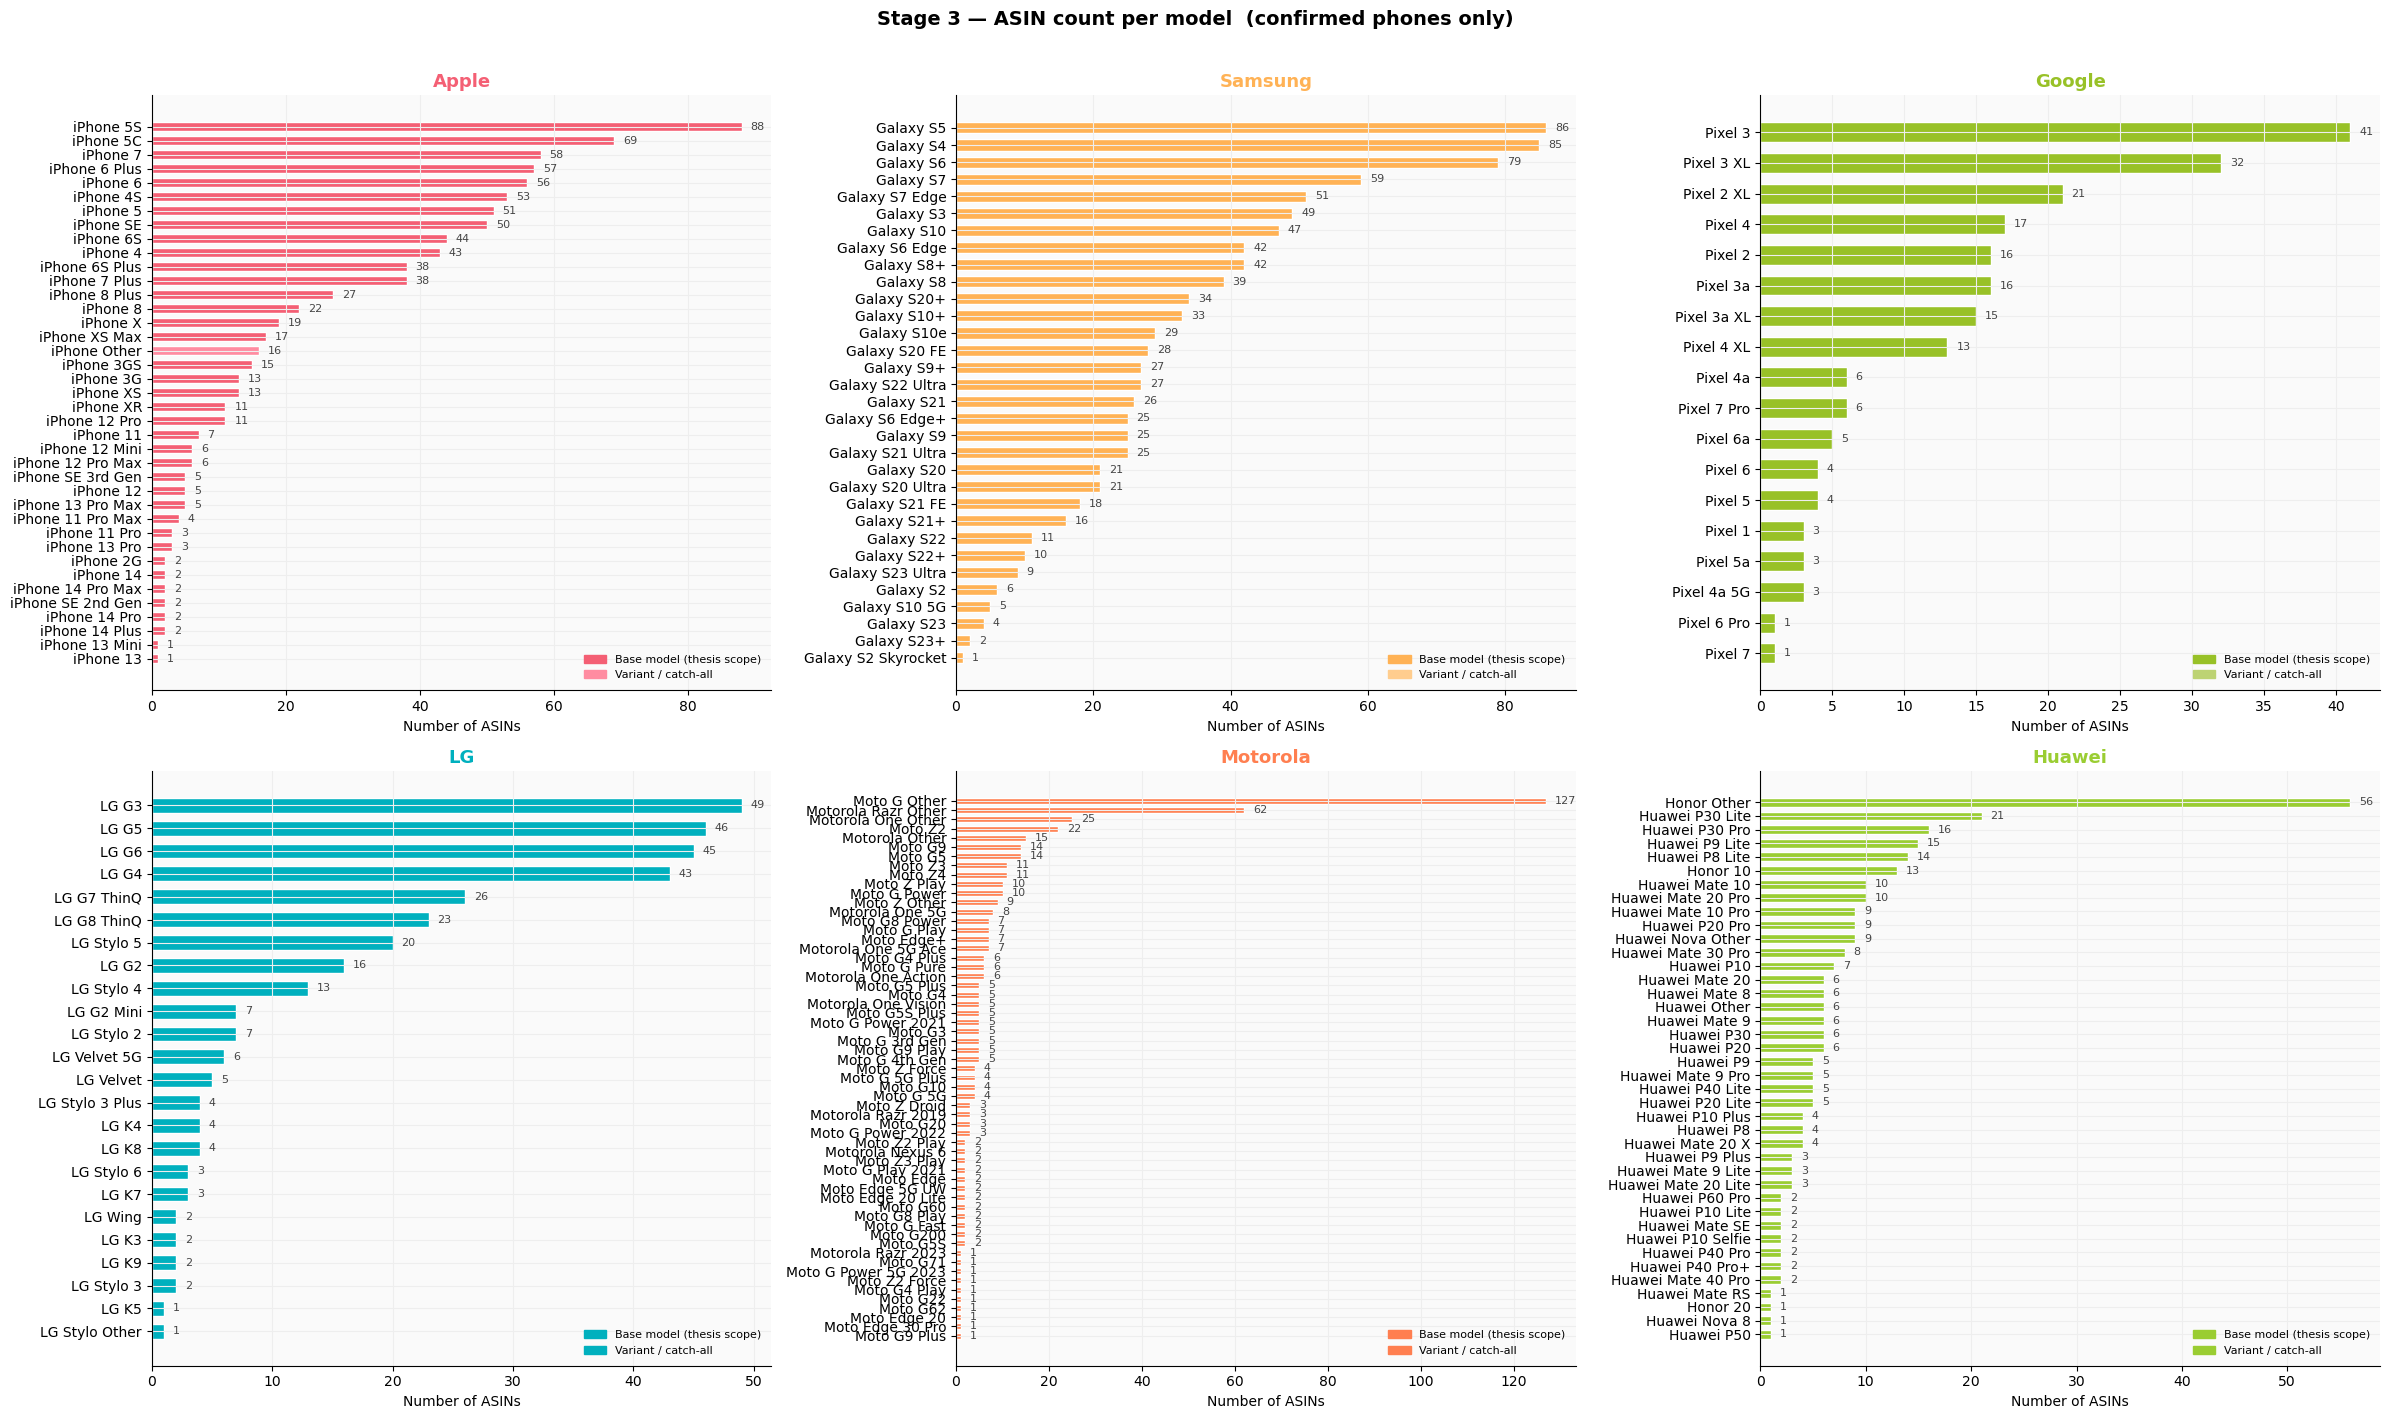

Saved: stage3_landscape.png


In [15]:
BASE_SCOPE = {
    'Apple': {
        # Original iPhone / legacy
        'iPhone 2G', 'iPhone 3G', 'iPhone 3GS',
        'iPhone 4', 'iPhone 4S',
        'iPhone 5', 'iPhone 5C', 'iPhone 5S',
        'iPhone 6', 'iPhone 6 Plus',
        'iPhone 6S', 'iPhone 6S Plus',
        'iPhone SE',
        'iPhone 7', 'iPhone 7 Plus',
        'iPhone 8', 'iPhone 8 Plus',
        # X family
        'iPhone X', 'iPhone XR', 'iPhone XS', 'iPhone XS Max',
        # iPhone 11
        'iPhone 11', 'iPhone 11 Pro', 'iPhone 11 Pro Max',
        # iPhone 12
        'iPhone SE 2nd Gen',
        'iPhone 12', 'iPhone 12 Mini', 'iPhone 12 Pro', 'iPhone 12 Pro Max',
        # iPhone 13
        'iPhone 13', 'iPhone 13 Mini', 'iPhone 13 Pro', 'iPhone 13 Pro Max',
        # iPhone 14
        'iPhone SE 3rd Gen',
        'iPhone 14', 'iPhone 14 Plus', 'iPhone 14 Pro', 'iPhone 14 Pro Max',
        # iPhone 15
        'iPhone 15', 'iPhone 15 Plus', 'iPhone 15 Pro', 'iPhone 15 Pro Max',
    },
    'Samsung': {
        # S-series legacy
        'Galaxy S2', 'Galaxy S2 Skyrocket',
        'Galaxy S3', 'Galaxy S4', 'Galaxy S5',
        'Galaxy S6', 'Galaxy S6 Edge', 'Galaxy S6 Edge+',
        'Galaxy S7', 'Galaxy S7 Edge',
        'Galaxy S8', 'Galaxy S8+',
        'Galaxy S9', 'Galaxy S9+',
        'Galaxy S10', 'Galaxy S10e', 'Galaxy S10+', 'Galaxy S10 5G',
        # S20 family
        'Galaxy S20', 'Galaxy S20+', 'Galaxy S20 FE', 'Galaxy S20 Ultra',
        # S21 family
        'Galaxy S21', 'Galaxy S21+', 'Galaxy S21 FE', 'Galaxy S21 Ultra',
        # S22 family
        'Galaxy S22', 'Galaxy S22+', 'Galaxy S22 Ultra',
        # S23 family
        'Galaxy S23', 'Galaxy S23+', 'Galaxy S23 FE', 'Galaxy S23 Ultra',
        # J-series
        'Galaxy J3', 'Galaxy J7', 'Galaxy J7 Crown', 'Galaxy J7 Refine',
        # A-series
        'Galaxy A10', 'Galaxy A11', 'Galaxy A12',
        'Galaxy A21', 'Galaxy A32',
        'Galaxy A51', 'Galaxy A52', 'Galaxy A53',
    },
    'Google': {
        # Pixel 1
        'Pixel 1',
        # Pixel 2 family
        'Pixel 2', 'Pixel 2 XL',
        # Pixel 3 family
        'Pixel 3', 'Pixel 3 XL', 'Pixel 3a', 'Pixel 3a XL',
        # Pixel 4 family
        'Pixel 4', 'Pixel 4 XL', 'Pixel 4a', 'Pixel 4a 5G',
        # Pixel 5 family
        'Pixel 5', 'Pixel 5a',
        # Pixel 6 family
        'Pixel 6', 'Pixel 6a', 'Pixel 6 Pro',
        # Pixel 7 family
        'Pixel 7', 'Pixel 7 Pro',
    },
    'LG': {
        # G-series
        'LG G2', 'LG G2 Mini',
        'LG G3', 'LG G4', 'LG G5', 'LG G6',
        'LG G7 ThinQ', 'LG G8 ThinQ', 'LG G8S ThinQ', 'LG G8X ThinQ',
        # V-series
        'LG V30', 'LG V35 ThinQ', 'LG V40 ThinQ', 'LG V50 ThinQ', 'LG V60 ThinQ',
        # Last flagships
        'LG Velvet', 'LG Velvet 5G', 'LG Wing',
        # Stylo series
        'LG Stylo 2', 'LG Stylo 3', 'LG Stylo 3 Plus',
        'LG Stylo 4', 'LG Stylo 5', 'LG Stylo 6',
        # K-series
        'LG K3', 'LG K4', 'LG K5', 'LG K7', 'LG K8', 'LG K9',
        'LG K10', 'LG K20', 'LG K30', 'LG K40',
        'LG K42', 'LG K51', 'LG K71', 'LG K92',
    },
    'Motorola': {
        # Edge series
        'Moto Edge', 'Moto Edge+', 'Moto Edge 5G UW',
        'Moto Edge 20', 'Moto Edge 20 Fusion', 'Moto Edge 20 Lite', 'Moto Edge 20 Pro',
        'Moto Edge 30', 'Moto Edge 30 Fusion', 'Moto Edge 30 Neo',
        'Moto Edge 30 Pro', 'Moto Edge 30 Ultra',
        'Moto Edge 40', 'Moto Edge 40 Neo', 'Moto Edge 40 Pro',
        # Razr — classic
        'Motorola Razr V3', 'Motorola Razr V3i', 'Motorola Razr V3m',
        'Motorola Razr V3t', 'Motorola Razr V3xx', 'Motorola Razr2 V9',
        # Razr — modern
        'Motorola Razr 2019', 'Motorola Razr 2020', 'Motorola Razr 5G',
        'Motorola Razr 2022', 'Motorola Razr 2023',
        # Z-series
        'Moto Z Droid', 'Moto Z Force',
        'Moto Z Play', 'Moto Z2', 'Moto Z2 Force', 'Moto Z2 Play',
        'Moto Z3', 'Moto Z3 Play', 'Moto Z4',
        # G3/G4/G5 families
        'Moto G3',
        'Moto G4', 'Moto G4 Play', 'Moto G4 Plus',
        'Moto G 3rd Gen', 'Moto G 4th Gen', 'Moto G 5th Gen',
        'Moto G5', 'Moto G5 Plus', 'Moto G5S', 'Moto G5S Plus',
        # G6/G7 families
        'Moto G6', 'Moto G6 Play', 'Moto G6 Plus',
        'Moto G7', 'Moto G7 Play', 'Moto G7 Plus', 'Moto G7 Power',
        # G8/G9 families
        'Moto G8', 'Moto G8 Play', 'Moto G8 Power',
        'Moto G9', 'Moto G9 Play', 'Moto G9 Plus',
        # G-series numbered / named
        'Moto G Fast', 'Moto G 5G', 'Moto G 5G Plus', 'Moto G Pure',
        'Moto G10', 'Moto G20', 'Moto G22', 'Moto G30', 'Moto G32',
        'Moto G50', 'Moto G51', 'Moto G53', 'Moto G60', 'Moto G62',
        'Moto G71', 'Moto G82', 'Moto G200',
        # G Play family
        'Moto G Play', 'Moto G Play 2021', 'Moto G Play 2022', 'Moto G Play 2023',
        # G Power family
        'Moto G Power',
        'Moto G Power 2021', 'Moto G Power 2022',
        'Moto G Power 2023', 'Moto G Power 5G 2023',
        # G Stylus family
        'Moto G Stylus',
        'Moto G Stylus 2021', 'Moto G Stylus 2022',
        'Moto G Stylus 5G', 'Moto G Stylus 5G 2021',
        'Moto G Stylus 5G 2022', 'Moto G Stylus 5G 2023',
        # E-series
        'Moto E4', 'Moto E4 Plus',
        'Moto E5', 'Moto E5 Play', 'Moto E5 Plus',
        'Moto E6', 'Moto E6 Plus',
        # One series
        'Motorola One Action', 'Motorola One Vision',
        'Motorola One 5G', 'Motorola One 5G Ace',
        # Other
        'Motorola Nexus 6',
    },
    'Huawei': {
        # P-series
        'Huawei P8', 'Huawei P8 Lite',
        'Huawei P9', 'Huawei P9 Lite', 'Huawei P9 Plus',
        'Huawei P10', 'Huawei P10 Lite', 'Huawei P10 Plus', 'Huawei P10 Selfie',
        'Huawei P20', 'Huawei P20 Lite', 'Huawei P20 Pro',
        'Huawei P30', 'Huawei P30 Lite', 'Huawei P30 Pro',
        'Huawei P40', 'Huawei P40 Lite', 'Huawei P40 Pro', 'Huawei P40 Pro+',
        'Huawei P50', 'Huawei P50 Pro',
        'Huawei P60', 'Huawei P60 Pro',
        # Mate-series
        'Huawei Mate 8',
        'Huawei Mate 9', 'Huawei Mate 9 Lite', 'Huawei Mate 9 Pro',
        'Huawei Mate 10', 'Huawei Mate 10 Pro', 'Huawei Mate SE', 'Huawei Mate RS',
        'Huawei Mate 20', 'Huawei Mate 20 Lite', 'Huawei Mate 20 Pro', 'Huawei Mate 20 X',
        'Huawei Mate 30', 'Huawei Mate 30 Pro',
        'Huawei Mate 40', 'Huawei Mate 40 Pro',
        # Nova series
        'Huawei Nova 3', 'Huawei Nova 3i', 'Huawei Nova 4e', 'Huawei Nova 5T',
        'Huawei Nova 7', 'Huawei Nova 8', 'Huawei Nova 9',
        # Honor sub-brand
        'Honor 3', 'Honor 3C',
        'Honor 4',
        'Honor 5A', 'Honor 5X',
        'Honor 6', 'Honor 6X',
        'Honor 7A', 'Honor 7C', 'Honor 7S', 'Honor 7X',
        'Honor 8', 'Honor 8A', 'Honor 8S', 'Honor 8X', 'Honor 8X Max',
        'Honor 9', 'Honor 9X', 'Honor 9X Pro',
        'Honor 10',
        'Honor 20', 'Honor View 20',
        'Honor 30',
        'Honor 50',
    },
}

BRAND_ORDER = ['Apple', 'Samsung', 'Google', 'LG', 'Motorola', 'Huawei']

fig, axes = plt.subplots(2, 3, figsize=(24, 14))
fig.suptitle('Stage 3 — ASIN count per model  (confirmed phones only)',
             fontsize=14, fontweight='bold', y=1.01)

for ax, brand in zip(axes.flatten(), BRAND_ORDER):
    rows = sorted([(k, len(v)) for k, v in model_asins.items()
                   if model_brand.get(k) == brand], key=lambda x: x[1])
    if not rows:
        ax.set_visible(False)
        continue
    labels = [m for m, _ in rows]
    values = [n for _, n in rows]
    colors = [BRAND_COLOR[brand] if lbl in BASE_SCOPE[brand]
              else BRAND_LIGHT[brand] for lbl in labels]
    bars = ax.barh(labels, values, color=colors, edgecolor='white', height=0.65)
    for bar, v in zip(bars, values):
        ax.text(v + max(values)*0.015, bar.get_y()+bar.get_height()/2,
                str(v), va='center', fontsize=8, color='#444')
    ax.set_title(brand, fontweight='bold', fontsize=13, color=BRAND_COLOR[brand])
    ax.set_xlabel('Number of ASINs')
    ax.legend(handles=[
        mpatches.Patch(color=BRAND_COLOR[brand], label='Base model (thesis scope)'),
        mpatches.Patch(color=BRAND_LIGHT[brand], label='Variant / catch-all'),
    ], frameon=False, fontsize=8, loc='lower right')

plt.tight_layout()
plt.savefig('stage3_landscape.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: stage3_landscape.png')


## Stage 4 — Thesis event selection

`candidate_asins` is **auto-populated from Stage 3 output** via `MODEL_KEY_MAP`.
No manual ASIN lists required — if Stage 3 finds it, it flows through automatically.

Events with 0 ASINs at this stage have no confirmed phone listings in the metadata
and cannot proceed to review loading.


In [17]:
def _c(pattern):
    return re.compile(pattern, re.IGNORECASE)

PHONE_EVENTS = {
    # ── Hedonic — Apple iPhone ─────────────────────────────────────────────────
    'iPhone 2G':              {'launch': '2007-06-29', 'type': 'hedonic', 'brand': 'Apple'},
    'iPhone 3G':              {'launch': '2008-07-11', 'type': 'hedonic', 'brand': 'Apple'},
    'iPhone 3GS':             {'launch': '2009-06-19', 'type': 'hedonic', 'brand': 'Apple'},
    'iPhone 4':               {'launch': '2010-06-24', 'type': 'hedonic', 'brand': 'Apple'},
    'iPhone 4S':              {'launch': '2011-10-14', 'type': 'hedonic', 'brand': 'Apple'},
    'iPhone 5':               {'launch': '2012-09-21', 'type': 'hedonic', 'brand': 'Apple'},
    'iPhone 5C':              {'launch': '2013-09-20', 'type': 'hedonic', 'brand': 'Apple'},
    'iPhone 5S':              {'launch': '2013-09-20', 'type': 'hedonic', 'brand': 'Apple'},
    'iPhone 6':               {'launch': '2014-09-19', 'type': 'hedonic', 'brand': 'Apple'},
    'iPhone 6 Plus':          {'launch': '2014-09-19', 'type': 'hedonic', 'brand': 'Apple'},
    'iPhone 6S':              {'launch': '2015-09-25', 'type': 'hedonic', 'brand': 'Apple'},
    'iPhone 6S Plus':         {'launch': '2015-09-25', 'type': 'hedonic', 'brand': 'Apple'},
    'iPhone SE':              {'launch': '2016-03-31', 'type': 'hedonic', 'brand': 'Apple'},
    'iPhone 7':               {'launch': '2016-09-16', 'type': 'hedonic', 'brand': 'Apple'},
    'iPhone 7 Plus':          {'launch': '2016-09-16', 'type': 'hedonic', 'brand': 'Apple'},
    'iPhone 8':               {'launch': '2017-09-22', 'type': 'hedonic', 'brand': 'Apple'},
    'iPhone 8 Plus':          {'launch': '2017-09-22', 'type': 'hedonic', 'brand': 'Apple'},
    'iPhone X':               {'launch': '2017-11-03', 'type': 'hedonic', 'brand': 'Apple'},
    'iPhone XR':              {'launch': '2018-10-26', 'type': 'hedonic', 'brand': 'Apple'},
    'iPhone XS':              {'launch': '2018-09-21', 'type': 'hedonic', 'brand': 'Apple'},
    'iPhone XS Max':          {'launch': '2018-09-21', 'type': 'hedonic', 'brand': 'Apple'},
    'iPhone 11':              {'launch': '2019-09-20', 'type': 'hedonic', 'brand': 'Apple'},
    'iPhone 11 Pro':          {'launch': '2019-09-20', 'type': 'hedonic', 'brand': 'Apple'},
    'iPhone 11 Pro Max':      {'launch': '2019-09-20', 'type': 'hedonic', 'brand': 'Apple'},
    'iPhone SE 2nd Gen':      {'launch': '2020-04-24', 'type': 'hedonic', 'brand': 'Apple'},
    'iPhone 12':              {'launch': '2020-10-23', 'type': 'hedonic', 'brand': 'Apple'},
    'iPhone 12 Mini':         {'launch': '2020-10-23', 'type': 'hedonic', 'brand': 'Apple'},
    'iPhone 12 Pro':          {'launch': '2020-10-23', 'type': 'hedonic', 'brand': 'Apple'},
    'iPhone 12 Pro Max':      {'launch': '2020-11-13', 'type': 'hedonic', 'brand': 'Apple'},
    'iPhone 13':              {'launch': '2021-09-24', 'type': 'hedonic', 'brand': 'Apple'},
    'iPhone 13 Mini':         {'launch': '2021-09-24', 'type': 'hedonic', 'brand': 'Apple'},
    'iPhone 13 Pro':          {'launch': '2021-09-24', 'type': 'hedonic', 'brand': 'Apple'},
    'iPhone 13 Pro Max':      {'launch': '2021-09-24', 'type': 'hedonic', 'brand': 'Apple'},
    'iPhone SE 3rd Gen':      {'launch': '2022-03-18', 'type': 'hedonic', 'brand': 'Apple'},
    'iPhone 14':              {'launch': '2022-09-16', 'type': 'hedonic', 'brand': 'Apple'},
    'iPhone 14 Plus':         {'launch': '2022-10-07', 'type': 'hedonic', 'brand': 'Apple'},
    'iPhone 14 Pro':          {'launch': '2022-09-16', 'type': 'hedonic', 'brand': 'Apple'},
    'iPhone 14 Pro Max':      {'launch': '2022-09-16', 'type': 'hedonic', 'brand': 'Apple'},
    'iPhone 15':              {'launch': '2023-09-22', 'type': 'hedonic', 'brand': 'Apple'},
    'iPhone 15 Plus':         {'launch': '2023-09-22', 'type': 'hedonic', 'brand': 'Apple'},
    'iPhone 15 Pro':          {'launch': '2023-09-22', 'type': 'hedonic', 'brand': 'Apple'},
    'iPhone 15 Pro Max':      {'launch': '2023-09-22', 'type': 'hedonic', 'brand': 'Apple'},

    # ── Hedonic — Samsung Galaxy S-series flagship ─────────────────────────────
    'Samsung Galaxy S2':          {'launch': '2011-05-01', 'type': 'hedonic', 'brand': 'Samsung'},
    'Samsung Galaxy S2 Skyrocket':{'launch': '2011-11-06', 'type': 'hedonic', 'brand': 'Samsung'},
    'Samsung Galaxy S3':          {'launch': '2012-05-29', 'type': 'hedonic', 'brand': 'Samsung'},
    'Samsung Galaxy S4':          {'launch': '2013-04-26', 'type': 'hedonic', 'brand': 'Samsung'},
    'Samsung Galaxy S5':          {'launch': '2014-04-11', 'type': 'hedonic', 'brand': 'Samsung'},
    'Samsung Galaxy S6':          {'launch': '2015-04-10', 'type': 'hedonic', 'brand': 'Samsung'},
    'Samsung Galaxy S6 Edge':     {'launch': '2015-04-10', 'type': 'hedonic', 'brand': 'Samsung'},
    'Samsung Galaxy S6 Edge+':    {'launch': '2015-08-21', 'type': 'hedonic', 'brand': 'Samsung'},
    'Samsung Galaxy S7':          {'launch': '2016-03-11', 'type': 'hedonic', 'brand': 'Samsung'},
    'Samsung Galaxy S7 Edge':     {'launch': '2016-03-11', 'type': 'hedonic', 'brand': 'Samsung'},
    'Samsung Galaxy S8':          {'launch': '2017-04-21', 'type': 'hedonic', 'brand': 'Samsung'},
    'Samsung Galaxy S8+':         {'launch': '2017-04-21', 'type': 'hedonic', 'brand': 'Samsung'},
    'Samsung Galaxy S9':          {'launch': '2018-03-16', 'type': 'hedonic', 'brand': 'Samsung'},
    'Samsung Galaxy S9+':         {'launch': '2018-03-16', 'type': 'hedonic', 'brand': 'Samsung'},
    'Samsung Galaxy S10':         {'launch': '2019-03-08', 'type': 'hedonic', 'brand': 'Samsung'},
    'Samsung Galaxy S10e':        {'launch': '2019-03-08', 'type': 'hedonic', 'brand': 'Samsung'},
    'Samsung Galaxy S10+':        {'launch': '2019-03-08', 'type': 'hedonic', 'brand': 'Samsung'},
    'Samsung Galaxy S10 5G':      {'launch': '2019-05-16', 'type': 'hedonic', 'brand': 'Samsung'},
    'Samsung Galaxy S20':         {'launch': '2020-03-06', 'type': 'hedonic', 'brand': 'Samsung'},
    'Samsung Galaxy S20+':        {'launch': '2020-03-06', 'type': 'hedonic', 'brand': 'Samsung'},
    'Samsung Galaxy S20 FE':      {'launch': '2020-10-02', 'type': 'hedonic', 'brand': 'Samsung'},
    'Samsung Galaxy S20 Ultra':   {'launch': '2020-03-06', 'type': 'hedonic', 'brand': 'Samsung'},
    'Samsung Galaxy S21':         {'launch': '2021-01-29', 'type': 'hedonic', 'brand': 'Samsung'},
    'Samsung Galaxy S21+':        {'launch': '2021-01-29', 'type': 'hedonic', 'brand': 'Samsung'},
    'Samsung Galaxy S21 FE':      {'launch': '2022-01-07', 'type': 'hedonic', 'brand': 'Samsung'},
    'Samsung Galaxy S21 Ultra':   {'launch': '2021-01-29', 'type': 'hedonic', 'brand': 'Samsung'},
    'Samsung Galaxy S22':         {'launch': '2022-02-25', 'type': 'hedonic', 'brand': 'Samsung'},
    'Samsung Galaxy S22+':        {'launch': '2022-02-25', 'type': 'hedonic', 'brand': 'Samsung'},
    'Samsung Galaxy S22 Ultra':   {'launch': '2022-02-25', 'type': 'hedonic', 'brand': 'Samsung'},
    'Samsung Galaxy S23':         {'launch': '2023-02-17', 'type': 'hedonic', 'brand': 'Samsung'},
    'Samsung Galaxy S23+':        {'launch': '2023-02-17', 'type': 'hedonic', 'brand': 'Samsung'},
    'Samsung Galaxy S23 FE':      {'launch': '2023-10-05', 'type': 'hedonic', 'brand': 'Samsung'},
    'Samsung Galaxy S23 Ultra':   {'launch': '2023-02-17', 'type': 'hedonic', 'brand': 'Samsung'},

    # ── Utilitarian — Samsung Galaxy J-series ─────────────────────────────────
    'Samsung Galaxy J3':          {'launch': '2016-06-05', 'type': 'utilitarian', 'brand': 'Samsung'},
    'Samsung Galaxy J7':          {'launch': '2015-07-01', 'type': 'utilitarian', 'brand': 'Samsung'},
    'Samsung Galaxy J7 Crown':    {'launch': '2018-05-18', 'type': 'utilitarian', 'brand': 'Samsung'},
    'Samsung Galaxy J7 Refine':   {'launch': '2018-01-12', 'type': 'utilitarian', 'brand': 'Samsung'},

    # ── Utilitarian — Samsung Galaxy A-series ─────────────────────────────────
    'Samsung Galaxy A10':         {'launch': '2019-03-01', 'type': 'utilitarian', 'brand': 'Samsung'},
    'Samsung Galaxy A11':         {'launch': '2020-05-08', 'type': 'utilitarian', 'brand': 'Samsung'},
    'Samsung Galaxy A12':         {'launch': '2020-11-20', 'type': 'utilitarian', 'brand': 'Samsung'},
    'Samsung Galaxy A21':         {'launch': '2020-06-12', 'type': 'utilitarian', 'brand': 'Samsung'},
    'Samsung Galaxy A32':         {'launch': '2021-02-25', 'type': 'utilitarian', 'brand': 'Samsung'},
    'Samsung Galaxy A51':         {'launch': '2020-01-29', 'type': 'utilitarian', 'brand': 'Samsung'},
    'Samsung Galaxy A52':         {'launch': '2021-03-26', 'type': 'utilitarian', 'brand': 'Samsung'},
    'Samsung Galaxy A53':         {'launch': '2022-04-01', 'type': 'utilitarian', 'brand': 'Samsung'},

    # ── Utilitarian — Google Pixel ─────────────────────────────────────────────
    'Google Pixel 1':             {'launch': '2016-10-20', 'type': 'utilitarian', 'brand': 'Google'},
    'Google Pixel 2':             {'launch': '2017-10-19', 'type': 'utilitarian', 'brand': 'Google'},
    'Google Pixel 2 XL':          {'launch': '2017-10-19', 'type': 'utilitarian', 'brand': 'Google'},
    'Google Pixel 3':             {'launch': '2018-10-18', 'type': 'utilitarian', 'brand': 'Google'},
    'Google Pixel 3 XL':          {'launch': '2018-10-18', 'type': 'utilitarian', 'brand': 'Google'},
    'Google Pixel 3a':            {'launch': '2019-05-07', 'type': 'utilitarian', 'brand': 'Google'},
    'Google Pixel 3a XL':         {'launch': '2019-05-07', 'type': 'utilitarian', 'brand': 'Google'},
    'Google Pixel 4':             {'launch': '2019-10-24', 'type': 'utilitarian', 'brand': 'Google'},
    'Google Pixel 4 XL':          {'launch': '2019-10-24', 'type': 'utilitarian', 'brand': 'Google'},
    'Google Pixel 4a':            {'launch': '2020-08-20', 'type': 'utilitarian', 'brand': 'Google'},
    'Google Pixel 4a 5G':         {'launch': '2020-10-29', 'type': 'utilitarian', 'brand': 'Google'},
    'Google Pixel 5':             {'launch': '2020-10-15', 'type': 'utilitarian', 'brand': 'Google'},
    'Google Pixel 5a':            {'launch': '2021-08-26', 'type': 'utilitarian', 'brand': 'Google'},
    'Google Pixel 6':             {'launch': '2021-10-28', 'type': 'utilitarian', 'brand': 'Google'},
    'Google Pixel 6a':            {'launch': '2022-07-28', 'type': 'utilitarian', 'brand': 'Google'},
    'Google Pixel 6 Pro':         {'launch': '2021-10-28', 'type': 'utilitarian', 'brand': 'Google'},
    'Google Pixel 7':             {'launch': '2022-10-13', 'type': 'utilitarian', 'brand': 'Google'},
    'Google Pixel 7 Pro':         {'launch': '2022-10-13', 'type': 'utilitarian', 'brand': 'Google'},

    # ── Hedonic — LG flagship (V/G-series, Velvet, Wing) ──────────────────────
    'LG G2':                  {'launch': '2013-08-07', 'type': 'hedonic', 'brand': 'LG'},
    'LG G2 Mini':             {'launch': '2014-03-01', 'type': 'utilitarian', 'brand': 'LG'},
    'LG G3':                  {'launch': '2014-07-17', 'type': 'hedonic', 'brand': 'LG'},
    'LG G4':                  {'launch': '2015-04-29', 'type': 'hedonic', 'brand': 'LG'},
    'LG G5':                  {'launch': '2016-04-01', 'type': 'hedonic', 'brand': 'LG'},
    'LG G6':                  {'launch': '2017-04-07', 'type': 'hedonic', 'brand': 'LG'},
    'LG G7 ThinQ':            {'launch': '2018-05-02', 'type': 'hedonic', 'brand': 'LG'},
    'LG G8 ThinQ':            {'launch': '2019-03-22', 'type': 'hedonic', 'brand': 'LG'},
    'LG G8S ThinQ':           {'launch': '2019-05-20', 'type': 'hedonic', 'brand': 'LG'},
    'LG G8X ThinQ':           {'launch': '2019-10-01', 'type': 'hedonic', 'brand': 'LG'},
    'LG V30':                 {'launch': '2017-09-15', 'type': 'hedonic', 'brand': 'LG'},
    'LG V35 ThinQ':           {'launch': '2018-06-01', 'type': 'hedonic', 'brand': 'LG'},
    'LG V40 ThinQ':           {'launch': '2018-10-04', 'type': 'hedonic', 'brand': 'LG'},
    'LG V50 ThinQ':           {'launch': '2019-05-31', 'type': 'hedonic', 'brand': 'LG'},
    'LG V60 ThinQ':           {'launch': '2020-03-05', 'type': 'hedonic', 'brand': 'LG'},
    'LG Velvet':              {'launch': '2020-06-15', 'type': 'hedonic', 'brand': 'LG'},
    'LG Velvet 5G':           {'launch': '2020-06-15', 'type': 'hedonic', 'brand': 'LG'},
    'LG Wing':                {'launch': '2020-10-15', 'type': 'hedonic', 'brand': 'LG'},

    # ── Utilitarian — LG mid-range (Stylo, K-series) ──────────────────────────
    'LG Stylo 2':             {'launch': '2016-05-01', 'type': 'utilitarian', 'brand': 'LG'},
    'LG Stylo 3':             {'launch': '2017-06-01', 'type': 'utilitarian', 'brand': 'LG'},
    'LG Stylo 3 Plus':        {'launch': '2017-08-01', 'type': 'utilitarian', 'brand': 'LG'},
    'LG Stylo 4':             {'launch': '2018-06-22', 'type': 'utilitarian', 'brand': 'LG'},
    'LG Stylo 5':             {'launch': '2019-07-12', 'type': 'utilitarian', 'brand': 'LG'},
    'LG Stylo 6':             {'launch': '2020-04-01', 'type': 'utilitarian', 'brand': 'LG'},
    'LG K3':                  {'launch': '2016-01-01', 'type': 'utilitarian', 'brand': 'LG'},
    'LG K4':                  {'launch': '2016-01-01', 'type': 'utilitarian', 'brand': 'LG'},
    'LG K5':                  {'launch': '2016-01-01', 'type': 'utilitarian', 'brand': 'LG'},
    'LG K7':                  {'launch': '2016-01-01', 'type': 'utilitarian', 'brand': 'LG'},
    'LG K8':                  {'launch': '2016-01-01', 'type': 'utilitarian', 'brand': 'LG'},
    'LG K9':                  {'launch': '2018-01-01', 'type': 'utilitarian', 'brand': 'LG'},
    'LG K10':                 {'launch': '2016-01-01', 'type': 'utilitarian', 'brand': 'LG'},
    'LG K20':                 {'launch': '2017-01-01', 'type': 'utilitarian', 'brand': 'LG'},
    'LG K30':                 {'launch': '2018-04-01', 'type': 'utilitarian', 'brand': 'LG'},
    'LG K40':                 {'launch': '2019-04-01', 'type': 'utilitarian', 'brand': 'LG'},
    'LG K42':                 {'launch': '2020-09-01', 'type': 'utilitarian', 'brand': 'LG'},
    'LG K51':                 {'launch': '2020-07-15', 'type': 'utilitarian', 'brand': 'LG'},
    'LG K71':                 {'launch': '2020-09-01', 'type': 'utilitarian', 'brand': 'LG'},
    'LG K92':                 {'launch': '2020-11-01', 'type': 'utilitarian', 'brand': 'LG'},

    # ── Hedonic — Motorola Edge series ────────────────────────────────────────
    'Moto Edge':              {'launch': '2020-10-25', 'type': 'hedonic', 'brand': 'Motorola'},
    'Moto Edge+':             {'launch': '2020-05-14', 'type': 'hedonic', 'brand': 'Motorola'},
    'Moto Edge 5G UW':        {'launch': '2020-10-01', 'type': 'hedonic', 'brand': 'Motorola'},
    'Moto Edge 20':           {'launch': '2021-08-09', 'type': 'hedonic', 'brand': 'Motorola'},
    'Moto Edge 20 Fusion':    {'launch': '2021-09-09', 'type': 'hedonic', 'brand': 'Motorola'},
    'Moto Edge 20 Lite':      {'launch': '2021-09-09', 'type': 'hedonic', 'brand': 'Motorola'},
    'Moto Edge 20 Pro':       {'launch': '2021-08-09', 'type': 'hedonic', 'brand': 'Motorola'},
    'Moto Edge 30':           {'launch': '2022-05-12', 'type': 'hedonic', 'brand': 'Motorola'},
    'Moto Edge 30 Fusion':    {'launch': '2022-09-08', 'type': 'hedonic', 'brand': 'Motorola'},
    'Moto Edge 30 Neo':       {'launch': '2022-09-08', 'type': 'hedonic', 'brand': 'Motorola'},
    'Moto Edge 30 Pro':       {'launch': '2022-02-24', 'type': 'hedonic', 'brand': 'Motorola'},
    'Moto Edge 30 Ultra':     {'launch': '2022-09-08', 'type': 'hedonic', 'brand': 'Motorola'},
    'Moto Edge 40':           {'launch': '2023-05-04', 'type': 'hedonic', 'brand': 'Motorola'},
    'Moto Edge 40 Neo':       {'launch': '2023-09-01', 'type': 'hedonic', 'brand': 'Motorola'},
    'Moto Edge 40 Pro':       {'launch': '2023-04-06', 'type': 'hedonic', 'brand': 'Motorola'},

    # ── Hedonic — Motorola Razr (classic + foldable) ──────────────────────────
    'Motorola Razr V3':       {'launch': '2004-07-01', 'type': 'hedonic', 'brand': 'Motorola'},
    'Motorola Razr V3i':      {'launch': '2005-09-01', 'type': 'hedonic', 'brand': 'Motorola'},
    'Motorola Razr V3m':      {'launch': '2005-11-01', 'type': 'hedonic', 'brand': 'Motorola'},
    'Motorola Razr V3t':      {'launch': '2005-11-01', 'type': 'hedonic', 'brand': 'Motorola'},
    'Motorola Razr V3xx':     {'launch': '2006-01-01', 'type': 'hedonic', 'brand': 'Motorola'},
    'Motorola Razr2 V9':      {'launch': '2007-09-01', 'type': 'hedonic', 'brand': 'Motorola'},
    'Motorola Razr 2019':     {'launch': '2020-01-09', 'type': 'hedonic', 'brand': 'Motorola'},
    'Motorola Razr 2020':     {'launch': '2020-10-02', 'type': 'hedonic', 'brand': 'Motorola'},
    'Motorola Razr 5G':       {'launch': '2020-09-09', 'type': 'hedonic', 'brand': 'Motorola'},
    'Motorola Razr 2022':     {'launch': '2022-09-01', 'type': 'hedonic', 'brand': 'Motorola'},
    'Motorola Razr 2023':     {'launch': '2023-06-01', 'type': 'hedonic', 'brand': 'Motorola'},

    # ── Hedonic — Motorola Z-series ───────────────────────────────────────────
    'Moto Z Droid':           {'launch': '2016-06-23', 'type': 'hedonic', 'brand': 'Motorola'},
    'Moto Z Force':           {'launch': '2016-07-28', 'type': 'hedonic', 'brand': 'Motorola'},
    'Moto Z Play':            {'launch': '2016-09-09', 'type': 'hedonic', 'brand': 'Motorola'},
    'Moto Z2':                {'launch': '2017-07-25', 'type': 'hedonic', 'brand': 'Motorola'},
    'Moto Z2 Force':          {'launch': '2017-08-10', 'type': 'hedonic', 'brand': 'Motorola'},
    'Moto Z2 Play':           {'launch': '2017-07-25', 'type': 'hedonic', 'brand': 'Motorola'},
    'Moto Z3':                {'launch': '2018-08-16', 'type': 'hedonic', 'brand': 'Motorola'},
    'Moto Z3 Play':           {'launch': '2018-06-07', 'type': 'hedonic', 'brand': 'Motorola'},
    'Moto Z4':                {'launch': '2019-06-06', 'type': 'hedonic', 'brand': 'Motorola'},

    # ── Utilitarian — Motorola G-series ───────────────────────────────────────
    'Moto G3':                {'launch': '2015-07-28', 'type': 'utilitarian', 'brand': 'Motorola'},
    'Moto G 3rd Gen':         {'launch': '2015-07-28', 'type': 'utilitarian', 'brand': 'Motorola'},
    'Moto G4':                {'launch': '2016-05-17', 'type': 'utilitarian', 'brand': 'Motorola'},
    'Moto G4 Play':           {'launch': '2016-07-12', 'type': 'utilitarian', 'brand': 'Motorola'},
    'Moto G4 Plus':           {'launch': '2016-05-17', 'type': 'utilitarian', 'brand': 'Motorola'},
    'Moto G 4th Gen':         {'launch': '2016-05-17', 'type': 'utilitarian', 'brand': 'Motorola'},
    'Moto G5':                {'launch': '2017-03-01', 'type': 'utilitarian', 'brand': 'Motorola'},
    'Moto G5 Plus':           {'launch': '2017-03-01', 'type': 'utilitarian', 'brand': 'Motorola'},
    'Moto G5S':               {'launch': '2017-08-24', 'type': 'utilitarian', 'brand': 'Motorola'},
    'Moto G5S Plus':          {'launch': '2017-08-24', 'type': 'utilitarian', 'brand': 'Motorola'},
    'Moto G 5th Gen':         {'launch': '2017-03-01', 'type': 'utilitarian', 'brand': 'Motorola'},
    'Moto G6':                {'launch': '2018-05-01', 'type': 'utilitarian', 'brand': 'Motorola'},
    'Moto G6 Play':           {'launch': '2018-05-01', 'type': 'utilitarian', 'brand': 'Motorola'},
    'Moto G6 Plus':           {'launch': '2018-05-01', 'type': 'utilitarian', 'brand': 'Motorola'},
    'Moto G7':                {'launch': '2019-02-07', 'type': 'utilitarian', 'brand': 'Motorola'},
    'Moto G7 Play':           {'launch': '2019-02-07', 'type': 'utilitarian', 'brand': 'Motorola'},
    'Moto G7 Plus':           {'launch': '2019-02-07', 'type': 'utilitarian', 'brand': 'Motorola'},
    'Moto G7 Power':          {'launch': '2019-02-07', 'type': 'utilitarian', 'brand': 'Motorola'},
    'Moto G8':                {'launch': '2019-10-24', 'type': 'utilitarian', 'brand': 'Motorola'},
    'Moto G8 Play':           {'launch': '2019-11-07', 'type': 'utilitarian', 'brand': 'Motorola'},
    'Moto G8 Power':          {'launch': '2020-01-01', 'type': 'utilitarian', 'brand': 'Motorola'},
    'Moto G9':                {'launch': '2020-08-24', 'type': 'utilitarian', 'brand': 'Motorola'},
    'Moto G9 Play':           {'launch': '2020-09-03', 'type': 'utilitarian', 'brand': 'Motorola'},
    'Moto G9 Plus':           {'launch': '2020-09-18', 'type': 'utilitarian', 'brand': 'Motorola'},
    'Moto G Fast':            {'launch': '2020-06-18', 'type': 'utilitarian', 'brand': 'Motorola'},
    'Moto G 5G':              {'launch': '2020-11-05', 'type': 'utilitarian', 'brand': 'Motorola'},
    'Moto G 5G Plus':         {'launch': '2020-07-01', 'type': 'utilitarian', 'brand': 'Motorola'},
    'Moto G Pure':            {'launch': '2021-10-01', 'type': 'utilitarian', 'brand': 'Motorola'},
    'Moto G10':               {'launch': '2021-03-01', 'type': 'utilitarian', 'brand': 'Motorola'},
    'Moto G20':               {'launch': '2021-04-01', 'type': 'utilitarian', 'brand': 'Motorola'},
    'Moto G22':               {'launch': '2022-04-01', 'type': 'utilitarian', 'brand': 'Motorola'},
    'Moto G30':               {'launch': '2021-03-01', 'type': 'utilitarian', 'brand': 'Motorola'},
    'Moto G32':               {'launch': '2022-08-01', 'type': 'utilitarian', 'brand': 'Motorola'},
    'Moto G50':               {'launch': '2021-07-01', 'type': 'utilitarian', 'brand': 'Motorola'},
    'Moto G51':               {'launch': '2021-11-01', 'type': 'utilitarian', 'brand': 'Motorola'},
    'Moto G53':               {'launch': '2023-01-01', 'type': 'utilitarian', 'brand': 'Motorola'},
    'Moto G60':               {'launch': '2021-05-01', 'type': 'utilitarian', 'brand': 'Motorola'},
    'Moto G62':               {'launch': '2022-07-01', 'type': 'utilitarian', 'brand': 'Motorola'},
    'Moto G71':               {'launch': '2021-12-01', 'type': 'utilitarian', 'brand': 'Motorola'},
    'Moto G82':               {'launch': '2022-05-01', 'type': 'utilitarian', 'brand': 'Motorola'},
    'Moto G200':              {'launch': '2021-11-01', 'type': 'utilitarian', 'brand': 'Motorola'},
    'Moto G Play':            {'launch': '2020-05-01', 'type': 'utilitarian', 'brand': 'Motorola'},
    'Moto G Play 2021':       {'launch': '2021-01-14', 'type': 'utilitarian', 'brand': 'Motorola'},
    'Moto G Play 2022':       {'launch': '2022-01-01', 'type': 'utilitarian', 'brand': 'Motorola'},
    'Moto G Play 2023':       {'launch': '2023-01-01', 'type': 'utilitarian', 'brand': 'Motorola'},
    'Moto G Power':           {'launch': '2020-02-07', 'type': 'utilitarian', 'brand': 'Motorola'},
    'Moto G Power 2021':      {'launch': '2021-01-14', 'type': 'utilitarian', 'brand': 'Motorola'},
    'Moto G Power 2022':      {'launch': '2022-02-24', 'type': 'utilitarian', 'brand': 'Motorola'},
    'Moto G Power 2023':      {'launch': '2023-03-01', 'type': 'utilitarian', 'brand': 'Motorola'},
    'Moto G Power 5G 2023':   {'launch': '2023-06-01', 'type': 'utilitarian', 'brand': 'Motorola'},
    'Moto G Stylus':          {'launch': '2020-03-01', 'type': 'utilitarian', 'brand': 'Motorola'},
    'Moto G Stylus 2021':     {'launch': '2021-04-01', 'type': 'utilitarian', 'brand': 'Motorola'},
    'Moto G Stylus 2022':     {'launch': '2022-04-01', 'type': 'utilitarian', 'brand': 'Motorola'},
    'Moto G Stylus 5G':       {'launch': '2022-05-01', 'type': 'utilitarian', 'brand': 'Motorola'},
    'Moto G Stylus 5G 2021':  {'launch': '2021-09-01', 'type': 'utilitarian', 'brand': 'Motorola'},
    'Moto G Stylus 5G 2022':  {'launch': '2022-05-01', 'type': 'utilitarian', 'brand': 'Motorola'},
    'Moto G Stylus 5G 2023':  {'launch': '2023-05-01', 'type': 'utilitarian', 'brand': 'Motorola'},

    # ── Utilitarian — Motorola E-series ───────────────────────────────────────
    'Moto E4':                {'launch': '2017-06-01', 'type': 'utilitarian', 'brand': 'Motorola'},
    'Moto E4 Plus':           {'launch': '2017-06-01', 'type': 'utilitarian', 'brand': 'Motorola'},
    'Moto E5':                {'launch': '2018-04-01', 'type': 'utilitarian', 'brand': 'Motorola'},
    'Moto E5 Play':           {'launch': '2018-09-01', 'type': 'utilitarian', 'brand': 'Motorola'},
    'Moto E5 Plus':           {'launch': '2018-04-01', 'type': 'utilitarian', 'brand': 'Motorola'},
    'Moto E6':                {'launch': '2019-08-16', 'type': 'utilitarian', 'brand': 'Motorola'},
    'Moto E6 Plus':           {'launch': '2019-09-01', 'type': 'utilitarian', 'brand': 'Motorola'},

    # ── Utilitarian — Motorola One series ─────────────────────────────────────
    'Motorola One Action':    {'launch': '2019-08-15', 'type': 'utilitarian', 'brand': 'Motorola'},
    'Motorola One Vision':    {'launch': '2019-05-15', 'type': 'utilitarian', 'brand': 'Motorola'},
    'Motorola One 5G':        {'launch': '2020-09-25', 'type': 'utilitarian', 'brand': 'Motorola'},
    'Motorola One 5G Ace':    {'launch': '2021-03-01', 'type': 'utilitarian', 'brand': 'Motorola'},

    # ── Utilitarian — Motorola other ──────────────────────────────────────────
    'Motorola Nexus 6':       {'launch': '2014-11-12', 'type': 'utilitarian', 'brand': 'Motorola'},

    # ── Hedonic — Huawei P-series flagship ────────────────────────────────────
    'Huawei P8':              {'launch': '2015-04-15', 'type': 'hedonic',     'brand': 'Huawei'},
    'Huawei P8 Lite':         {'launch': '2015-05-01', 'type': 'utilitarian', 'brand': 'Huawei'},
    'Huawei P9':              {'launch': '2016-04-06', 'type': 'hedonic',     'brand': 'Huawei'},
    'Huawei P9 Lite':         {'launch': '2016-05-01', 'type': 'utilitarian', 'brand': 'Huawei'},
    'Huawei P9 Plus':         {'launch': '2016-04-06', 'type': 'hedonic',     'brand': 'Huawei'},
    'Huawei P10':             {'launch': '2017-02-26', 'type': 'hedonic',     'brand': 'Huawei'},
    'Huawei P10 Lite':        {'launch': '2017-04-01', 'type': 'utilitarian', 'brand': 'Huawei'},
    'Huawei P10 Plus':        {'launch': '2017-02-26', 'type': 'hedonic',     'brand': 'Huawei'},
    'Huawei P10 Selfie':      {'launch': '2017-06-01', 'type': 'utilitarian', 'brand': 'Huawei'},
    'Huawei P20':             {'launch': '2018-04-06', 'type': 'hedonic',     'brand': 'Huawei'},
    'Huawei P20 Lite':        {'launch': '2018-04-06', 'type': 'utilitarian', 'brand': 'Huawei'},
    'Huawei P20 Pro':         {'launch': '2018-04-06', 'type': 'hedonic',     'brand': 'Huawei'},
    'Huawei P30':             {'launch': '2019-04-07', 'type': 'hedonic',     'brand': 'Huawei'},
    'Huawei P30 Lite':        {'launch': '2019-03-22', 'type': 'utilitarian', 'brand': 'Huawei'},
    'Huawei P30 Pro':         {'launch': '2019-04-07', 'type': 'hedonic',     'brand': 'Huawei'},
    'Huawei P40':             {'launch': '2020-03-26', 'type': 'hedonic',     'brand': 'Huawei'},
    'Huawei P40 Lite':        {'launch': '2020-03-26', 'type': 'utilitarian', 'brand': 'Huawei'},
    'Huawei P40 Pro':         {'launch': '2020-03-26', 'type': 'hedonic',     'brand': 'Huawei'},
    'Huawei P40 Pro+':        {'launch': '2020-03-26', 'type': 'hedonic',     'brand': 'Huawei'},
    'Huawei P50':             {'launch': '2021-07-29', 'type': 'hedonic',     'brand': 'Huawei'},
    'Huawei P50 Pro':         {'launch': '2021-07-29', 'type': 'hedonic',     'brand': 'Huawei'},
    'Huawei P60':             {'launch': '2023-03-23', 'type': 'hedonic',     'brand': 'Huawei'},
    'Huawei P60 Pro':         {'launch': '2023-03-23', 'type': 'hedonic',     'brand': 'Huawei'},

    # ── Hedonic — Huawei Mate-series ──────────────────────────────────────────
    'Huawei Mate 8':          {'launch': '2015-11-26', 'type': 'hedonic',     'brand': 'Huawei'},
    'Huawei Mate 9':          {'launch': '2016-11-03', 'type': 'hedonic',     'brand': 'Huawei'},
    'Huawei Mate 9 Lite':     {'launch': '2016-12-01', 'type': 'utilitarian', 'brand': 'Huawei'},
    'Huawei Mate 9 Pro':      {'launch': '2016-11-03', 'type': 'hedonic',     'brand': 'Huawei'},
    'Huawei Mate 10':         {'launch': '2017-10-16', 'type': 'hedonic',     'brand': 'Huawei'},
    'Huawei Mate 10 Pro':     {'launch': '2017-10-16', 'type': 'hedonic',     'brand': 'Huawei'},
    'Huawei Mate SE':         {'launch': '2018-02-01', 'type': 'utilitarian', 'brand': 'Huawei'},
    'Huawei Mate RS':         {'launch': '2018-03-27', 'type': 'hedonic',     'brand': 'Huawei'},
    'Huawei Mate 20':         {'launch': '2018-10-16', 'type': 'hedonic',     'brand': 'Huawei'},
    'Huawei Mate 20 Lite':    {'launch': '2018-09-05', 'type': 'utilitarian', 'brand': 'Huawei'},
    'Huawei Mate 20 Pro':     {'launch': '2018-10-16', 'type': 'hedonic',     'brand': 'Huawei'},
    'Huawei Mate 20 X':       {'launch': '2018-10-16', 'type': 'hedonic',     'brand': 'Huawei'},
    'Huawei Mate 30':         {'launch': '2019-09-19', 'type': 'hedonic',     'brand': 'Huawei'},
    'Huawei Mate 30 Pro':     {'launch': '2019-09-19', 'type': 'hedonic',     'brand': 'Huawei'},
    'Huawei Mate 40':         {'launch': '2020-10-22', 'type': 'hedonic',     'brand': 'Huawei'},
    'Huawei Mate 40 Pro':     {'launch': '2020-10-22', 'type': 'hedonic',     'brand': 'Huawei'},

    # ── Utilitarian — Huawei Nova series ──────────────────────────────────────
    'Huawei Nova 3':          {'launch': '2018-07-18', 'type': 'utilitarian', 'brand': 'Huawei'},
    'Huawei Nova 3i':         {'launch': '2018-07-18', 'type': 'utilitarian', 'brand': 'Huawei'},
    'Huawei Nova 4e':         {'launch': '2019-03-14', 'type': 'utilitarian', 'brand': 'Huawei'},
    'Huawei Nova 5T':         {'launch': '2019-09-05', 'type': 'utilitarian', 'brand': 'Huawei'},
    'Huawei Nova 7':          {'launch': '2020-04-23', 'type': 'utilitarian', 'brand': 'Huawei'},
    'Huawei Nova 8':          {'launch': '2020-12-02', 'type': 'utilitarian', 'brand': 'Huawei'},
    'Huawei Nova 9':          {'launch': '2021-10-13', 'type': 'utilitarian', 'brand': 'Huawei'},

    # ── Honor sub-brand (pre-2020 spinoff, listed under Huawei) ───────────────
    'Honor 3':                {'launch': '2013-07-01', 'type': 'utilitarian', 'brand': 'Huawei'},
    'Honor 3C':               {'launch': '2013-11-01', 'type': 'utilitarian', 'brand': 'Huawei'},
    'Honor 4':                {'launch': '2014-12-01', 'type': 'utilitarian', 'brand': 'Huawei'},
    'Honor 5A':               {'launch': '2016-05-01', 'type': 'utilitarian', 'brand': 'Huawei'},
    'Honor 5X':               {'launch': '2015-11-26', 'type': 'utilitarian', 'brand': 'Huawei'},
    'Honor 6':                {'launch': '2014-06-24', 'type': 'hedonic',     'brand': 'Huawei'},
    'Honor 6X':               {'launch': '2016-12-02', 'type': 'utilitarian', 'brand': 'Huawei'},
    'Honor 7A':               {'launch': '2018-03-01', 'type': 'utilitarian', 'brand': 'Huawei'},
    'Honor 7C':               {'launch': '2018-03-01', 'type': 'utilitarian', 'brand': 'Huawei'},
    'Honor 7S':               {'launch': '2018-07-01', 'type': 'utilitarian', 'brand': 'Huawei'},
    'Honor 7X':               {'launch': '2017-10-11', 'type': 'utilitarian', 'brand': 'Huawei'},
    'Honor 8':                {'launch': '2016-07-01', 'type': 'hedonic',     'brand': 'Huawei'},
    'Honor 8A':               {'launch': '2019-01-09', 'type': 'utilitarian', 'brand': 'Huawei'},
    'Honor 8S':               {'launch': '2019-03-01', 'type': 'utilitarian', 'brand': 'Huawei'},
    'Honor 8X':               {'launch': '2018-09-05', 'type': 'utilitarian', 'brand': 'Huawei'},
    'Honor 8X Max':           {'launch': '2018-09-05', 'type': 'utilitarian', 'brand': 'Huawei'},
    'Honor 9':                {'launch': '2017-06-12', 'type': 'hedonic',     'brand': 'Huawei'},
    'Honor 9X':               {'launch': '2019-07-23', 'type': 'utilitarian', 'brand': 'Huawei'},
    'Honor 9X Pro':           {'launch': '2019-07-23', 'type': 'utilitarian', 'brand': 'Huawei'},
    'Honor 10':               {'launch': '2018-05-15', 'type': 'utilitarian', 'brand': 'Huawei'},
    'Honor 20':               {'launch': '2019-05-21', 'type': 'hedonic',     'brand': 'Huawei'},
    'Honor View 20':          {'launch': '2019-01-22', 'type': 'hedonic',     'brand': 'Huawei'},
    'Honor 30':               {'launch': '2020-04-15', 'type': 'hedonic',     'brand': 'Huawei'},
    'Honor 50':               {'launch': '2021-06-02', 'type': 'hedonic',     'brand': 'Huawei'},
}

WINDOW_DAYS = 90

MODEL_KEY_MAP = {
    # ── Apple ──────────────────────────────────────────────────────────────────
    'iPhone 2G':              'iPhone 2G',
    'iPhone 3G':              'iPhone 3G',
    'iPhone 3GS':             'iPhone 3GS',
    'iPhone 4':               'iPhone 4',
    'iPhone 4S':              'iPhone 4S',
    'iPhone 5':               'iPhone 5',
    'iPhone 5C':              'iPhone 5C',
    'iPhone 5S':              'iPhone 5S',
    'iPhone 6':               'iPhone 6',
    'iPhone 6 Plus':          'iPhone 6 Plus',
    'iPhone 6S':              'iPhone 6S',
    'iPhone 6S Plus':         'iPhone 6S Plus',
    'iPhone SE':              'iPhone SE',
    'iPhone 7':               'iPhone 7',
    'iPhone 7 Plus':          'iPhone 7 Plus',
    'iPhone 8':               'iPhone 8',
    'iPhone 8 Plus':          'iPhone 8 Plus',
    'iPhone X':               'iPhone X',
    'iPhone XR':              'iPhone XR',
    'iPhone XS':              'iPhone XS',
    'iPhone XS Max':          'iPhone XS Max',
    'iPhone 11':              'iPhone 11',
    'iPhone 11 Pro':          'iPhone 11 Pro',
    'iPhone 11 Pro Max':      'iPhone 11 Pro Max',
    'iPhone SE 2nd Gen':      'iPhone SE 2nd Gen',
    'iPhone 12':              'iPhone 12',
    'iPhone 12 Mini':         'iPhone 12 Mini',
    'iPhone 12 Pro':          'iPhone 12 Pro',
    'iPhone 12 Pro Max':      'iPhone 12 Pro Max',
    'iPhone 13':              'iPhone 13',
    'iPhone 13 Mini':         'iPhone 13 Mini',
    'iPhone 13 Pro':          'iPhone 13 Pro',
    'iPhone 13 Pro Max':      'iPhone 13 Pro Max',
    'iPhone SE 3rd Gen':      'iPhone SE 3rd Gen',
    'iPhone 14':              'iPhone 14',
    'iPhone 14 Plus':         'iPhone 14 Plus',
    'iPhone 14 Pro':          'iPhone 14 Pro',
    'iPhone 14 Pro Max':      'iPhone 14 Pro Max',
    'iPhone 15':              'iPhone 15',
    'iPhone 15 Plus':         'iPhone 15 Plus',
    'iPhone 15 Pro':          'iPhone 15 Pro',
    'iPhone 15 Pro Max':      'iPhone 15 Pro Max',

    # ── Samsung ────────────────────────────────────────────────────────────────
    'Galaxy S2':              'Samsung Galaxy S2',
    'Galaxy S2 Skyrocket':    'Samsung Galaxy S2 Skyrocket',
    'Galaxy S3':              'Samsung Galaxy S3',
    'Galaxy S4':              'Samsung Galaxy S4',
    'Galaxy S5':              'Samsung Galaxy S5',
    'Galaxy S6':              'Samsung Galaxy S6',
    'Galaxy S6 Edge':         'Samsung Galaxy S6 Edge',
    'Galaxy S6 Edge+':        'Samsung Galaxy S6 Edge+',
    'Galaxy S7':              'Samsung Galaxy S7',
    'Galaxy S7 Edge':         'Samsung Galaxy S7 Edge',
    'Galaxy S8':              'Samsung Galaxy S8',
    'Galaxy S8+':             'Samsung Galaxy S8+',
    'Galaxy S9':              'Samsung Galaxy S9',
    'Galaxy S9+':             'Samsung Galaxy S9+',
    'Galaxy S10':             'Samsung Galaxy S10',
    'Galaxy S10e':            'Samsung Galaxy S10e',
    'Galaxy S10+':            'Samsung Galaxy S10+',
    'Galaxy S10 5G':          'Samsung Galaxy S10 5G',
    'Galaxy S20':             'Samsung Galaxy S20',
    'Galaxy S20+':            'Samsung Galaxy S20+',
    'Galaxy S20 FE':          'Samsung Galaxy S20 FE',
    'Galaxy S20 Ultra':       'Samsung Galaxy S20 Ultra',
    'Galaxy S21':             'Samsung Galaxy S21',
    'Galaxy S21+':            'Samsung Galaxy S21+',
    'Galaxy S21 FE':          'Samsung Galaxy S21 FE',
    'Galaxy S21 Ultra':       'Samsung Galaxy S21 Ultra',
    'Galaxy S22':             'Samsung Galaxy S22',
    'Galaxy S22+':            'Samsung Galaxy S22+',
    'Galaxy S22 Ultra':       'Samsung Galaxy S22 Ultra',
    'Galaxy S23':             'Samsung Galaxy S23',
    'Galaxy S23+':            'Samsung Galaxy S23+',
    'Galaxy S23 FE':          'Samsung Galaxy S23 FE',
    'Galaxy S23 Ultra':       'Samsung Galaxy S23 Ultra',
    'Galaxy J3':              'Samsung Galaxy J3',
    'Galaxy J7':              'Samsung Galaxy J7',
    'Galaxy J7 Crown':        'Samsung Galaxy J7 Crown',
    'Galaxy J7 Refine':       'Samsung Galaxy J7 Refine',
    'Galaxy A10':             'Samsung Galaxy A10',
    'Galaxy A11':             'Samsung Galaxy A11',
    'Galaxy A12':             'Samsung Galaxy A12',
    'Galaxy A21':             'Samsung Galaxy A21',
    'Galaxy A32':             'Samsung Galaxy A32',
    'Galaxy A51':             'Samsung Galaxy A51',
    'Galaxy A52':             'Samsung Galaxy A52',
    'Galaxy A53':             'Samsung Galaxy A53',

    # ── Google ─────────────────────────────────────────────────────────────────
    'Pixel 1':                'Google Pixel 1',
    'Pixel 2':                'Google Pixel 2',
    'Pixel 2 XL':             'Google Pixel 2 XL',
    'Pixel 3':                'Google Pixel 3',
    'Pixel 3 XL':             'Google Pixel 3 XL',
    'Pixel 3a':               'Google Pixel 3a',
    'Pixel 3a XL':            'Google Pixel 3a XL',
    'Pixel 4':                'Google Pixel 4',
    'Pixel 4 XL':             'Google Pixel 4 XL',
    'Pixel 4a':               'Google Pixel 4a',
    'Pixel 4a 5G':            'Google Pixel 4a 5G',
    'Pixel 5':                'Google Pixel 5',
    'Pixel 5a':               'Google Pixel 5a',
    'Pixel 6':                'Google Pixel 6',
    'Pixel 6a':               'Google Pixel 6a',
    'Pixel 6 Pro':            'Google Pixel 6 Pro',
    'Pixel 7':                'Google Pixel 7',
    'Pixel 7 Pro':            'Google Pixel 7 Pro',

    # ── LG ─────────────────────────────────────────────────────────────────────
    'LG G2':                  'LG G2',
    'LG G2 Mini':             'LG G2 Mini',
    'LG G3':                  'LG G3',
    'LG G4':                  'LG G4',
    'LG G5':                  'LG G5',
    'LG G6':                  'LG G6',
    'LG G7 ThinQ':            'LG G7 ThinQ',
    'LG G8 ThinQ':            'LG G8 ThinQ',
    'LG G8S ThinQ':           'LG G8S ThinQ',
    'LG G8X ThinQ':           'LG G8X ThinQ',
    'LG V30':                 'LG V30',
    'LG V35 ThinQ':           'LG V35 ThinQ',
    'LG V40 ThinQ':           'LG V40 ThinQ',
    'LG V50 ThinQ':           'LG V50 ThinQ',
    'LG V60 ThinQ':           'LG V60 ThinQ',
    'LG Velvet':              'LG Velvet',
    'LG Velvet 5G':           'LG Velvet 5G',
    'LG Wing':                'LG Wing',
    'LG Stylo 2':             'LG Stylo 2',
    'LG Stylo 3':             'LG Stylo 3',
    'LG Stylo 3 Plus':        'LG Stylo 3 Plus',
    'LG Stylo 4':             'LG Stylo 4',
    'LG Stylo 5':             'LG Stylo 5',
    'LG Stylo 6':             'LG Stylo 6',
    'LG K3':                  'LG K3',
    'LG K4':                  'LG K4',
    'LG K5':                  'LG K5',
    'LG K7':                  'LG K7',
    'LG K8':                  'LG K8',
    'LG K9':                  'LG K9',
    'LG K10':                 'LG K10',
    'LG K20':                 'LG K20',
    'LG K30':                 'LG K30',
    'LG K40':                 'LG K40',
    'LG K42':                 'LG K42',
    'LG K51':                 'LG K51',
    'LG K71':                 'LG K71',
    'LG K92':                 'LG K92',

    # ── Motorola ───────────────────────────────────────────────────────────────
    'Moto Edge':              'Moto Edge',
    'Moto Edge+':             'Moto Edge+',
    'Moto Edge 5G UW':        'Moto Edge 5G UW',
    'Moto Edge 20':           'Moto Edge 20',
    'Moto Edge 20 Fusion':    'Moto Edge 20 Fusion',
    'Moto Edge 20 Lite':      'Moto Edge 20 Lite',
    'Moto Edge 20 Pro':       'Moto Edge 20 Pro',
    'Moto Edge 30':           'Moto Edge 30',
    'Moto Edge 30 Fusion':    'Moto Edge 30 Fusion',
    'Moto Edge 30 Neo':       'Moto Edge 30 Neo',
    'Moto Edge 30 Pro':       'Moto Edge 30 Pro',
    'Moto Edge 30 Ultra':     'Moto Edge 30 Ultra',
    'Moto Edge 40':           'Moto Edge 40',
    'Moto Edge 40 Neo':       'Moto Edge 40 Neo',
    'Moto Edge 40 Pro':       'Moto Edge 40 Pro',
    'Motorola Razr V3':       'Motorola Razr V3',
    'Motorola Razr V3i':      'Motorola Razr V3i',
    'Motorola Razr V3m':      'Motorola Razr V3m',
    'Motorola Razr V3t':      'Motorola Razr V3t',
    'Motorola Razr V3xx':     'Motorola Razr V3xx',
    'Motorola Razr2 V9':      'Motorola Razr2 V9',
    'Motorola Razr 2019':     'Motorola Razr 2019',
    'Motorola Razr 2020':     'Motorola Razr 2020',
    'Motorola Razr 5G':       'Motorola Razr 5G',
    'Motorola Razr 2022':     'Motorola Razr 2022',
    'Motorola Razr 2023':     'Motorola Razr 2023',
    'Moto Z Droid':           'Moto Z Droid',
    'Moto Z Force':           'Moto Z Force',
    'Moto Z Play':            'Moto Z Play',
    'Moto Z2':                'Moto Z2',
    'Moto Z2 Force':          'Moto Z2 Force',
    'Moto Z2 Play':           'Moto Z2 Play',
    'Moto Z3':                'Moto Z3',
    'Moto Z3 Play':           'Moto Z3 Play',
    'Moto Z4':                'Moto Z4',
    'Moto G3':                'Moto G3',
    'Moto G 3rd Gen':         'Moto G 3rd Gen',
    'Moto G4':                'Moto G4',
    'Moto G4 Play':           'Moto G4 Play',
    'Moto G4 Plus':           'Moto G4 Plus',
    'Moto G 4th Gen':         'Moto G 4th Gen',
    'Moto G5':                'Moto G5',
    'Moto G5 Plus':           'Moto G5 Plus',
    'Moto G5S':               'Moto G5S',
    'Moto G5S Plus':          'Moto G5S Plus',
    'Moto G 5th Gen':         'Moto G 5th Gen',
    'Moto G6':                'Moto G6',
    'Moto G6 Play':           'Moto G6 Play',
    'Moto G6 Plus':           'Moto G6 Plus',
    'Moto G7':                'Moto G7',
    'Moto G7 Play':           'Moto G7 Play',
    'Moto G7 Plus':           'Moto G7 Plus',
    'Moto G7 Power':          'Moto G7 Power',
    'Moto G8':                'Moto G8',
    'Moto G8 Play':           'Moto G8 Play',
    'Moto G8 Power':          'Moto G8 Power',
    'Moto G9':                'Moto G9',
    'Moto G9 Play':           'Moto G9 Play',
    'Moto G9 Plus':           'Moto G9 Plus',
    'Moto G Fast':            'Moto G Fast',
    'Moto G 5G':              'Moto G 5G',
    'Moto G 5G Plus':         'Moto G 5G Plus',
    'Moto G Pure':            'Moto G Pure',
    'Moto G10':               'Moto G10',
    'Moto G20':               'Moto G20',
    'Moto G22':               'Moto G22',
    'Moto G30':               'Moto G30',
    'Moto G32':               'Moto G32',
    'Moto G50':               'Moto G50',
    'Moto G51':               'Moto G51',
    'Moto G53':               'Moto G53',
    'Moto G60':               'Moto G60',
    'Moto G62':               'Moto G62',
    'Moto G71':               'Moto G71',
    'Moto G82':               'Moto G82',
    'Moto G200':              'Moto G200',
    'Moto G Play':            'Moto G Play',
    'Moto G Play 2021':       'Moto G Play 2021',
    'Moto G Play 2022':       'Moto G Play 2022',
    'Moto G Play 2023':       'Moto G Play 2023',
    'Moto G Power':           'Moto G Power',
    'Moto G Power 2021':      'Moto G Power 2021',
    'Moto G Power 2022':      'Moto G Power 2022',
    'Moto G Power 2023':      'Moto G Power 2023',
    'Moto G Power 5G 2023':   'Moto G Power 5G 2023',
    'Moto G Stylus':          'Moto G Stylus',
    'Moto G Stylus 2021':     'Moto G Stylus 2021',
    'Moto G Stylus 2022':     'Moto G Stylus 2022',
    'Moto G Stylus 5G':       'Moto G Stylus 5G',
    'Moto G Stylus 5G 2021':  'Moto G Stylus 5G 2021',
    'Moto G Stylus 5G 2022':  'Moto G Stylus 5G 2022',
    'Moto G Stylus 5G 2023':  'Moto G Stylus 5G 2023',
    'Moto E4':                'Moto E4',
    'Moto E4 Plus':           'Moto E4 Plus',
    'Moto E5':                'Moto E5',
    'Moto E5 Play':           'Moto E5 Play',
    'Moto E5 Plus':           'Moto E5 Plus',
    'Moto E6':                'Moto E6',
    'Moto E6 Plus':           'Moto E6 Plus',
    'Motorola One Action':    'Motorola One Action',
    'Motorola One Vision':    'Motorola One Vision',
    'Motorola One 5G':        'Motorola One 5G',
    'Motorola One 5G Ace':    'Motorola One 5G Ace',
    'Motorola Nexus 6':       'Motorola Nexus 6',

    # ── Huawei ─────────────────────────────────────────────────────────────────
    'Huawei P8':              'Huawei P8',
    'Huawei P8 Lite':         'Huawei P8 Lite',
    'Huawei P9':              'Huawei P9',
    'Huawei P9 Lite':         'Huawei P9 Lite',
    'Huawei P9 Plus':         'Huawei P9 Plus',
    'Huawei P10':             'Huawei P10',
    'Huawei P10 Lite':        'Huawei P10 Lite',
    'Huawei P10 Plus':        'Huawei P10 Plus',
    'Huawei P10 Selfie':      'Huawei P10 Selfie',
    'Huawei P20':             'Huawei P20',
    'Huawei P20 Lite':        'Huawei P20 Lite',
    'Huawei P20 Pro':         'Huawei P20 Pro',
    'Huawei P30':             'Huawei P30',
    'Huawei P30 Lite':        'Huawei P30 Lite',
    'Huawei P30 Pro':         'Huawei P30 Pro',
    'Huawei P40':             'Huawei P40',
    'Huawei P40 Lite':        'Huawei P40 Lite',
    'Huawei P40 Pro':         'Huawei P40 Pro',
    'Huawei P40 Pro+':        'Huawei P40 Pro+',
    'Huawei P50':             'Huawei P50',
    'Huawei P50 Pro':         'Huawei P50 Pro',
    'Huawei P60':             'Huawei P60',
    'Huawei P60 Pro':         'Huawei P60 Pro',
    'Huawei Mate 8':          'Huawei Mate 8',
    'Huawei Mate 9':          'Huawei Mate 9',
    'Huawei Mate 9 Lite':     'Huawei Mate 9 Lite',
    'Huawei Mate 9 Pro':      'Huawei Mate 9 Pro',
    'Huawei Mate 10':         'Huawei Mate 10',
    'Huawei Mate 10 Pro':     'Huawei Mate 10 Pro',
    'Huawei Mate SE':         'Huawei Mate SE',
    'Huawei Mate RS':         'Huawei Mate RS',
    'Huawei Mate 20':         'Huawei Mate 20',
    'Huawei Mate 20 Lite':    'Huawei Mate 20 Lite',
    'Huawei Mate 20 Pro':     'Huawei Mate 20 Pro',
    'Huawei Mate 20 X':       'Huawei Mate 20 X',
    'Huawei Mate 30':         'Huawei Mate 30',
    'Huawei Mate 30 Pro':     'Huawei Mate 30 Pro',
    'Huawei Mate 40':         'Huawei Mate 40',
    'Huawei Mate 40 Pro':     'Huawei Mate 40 Pro',
    'Huawei Nova 3':          'Huawei Nova 3',
    'Huawei Nova 3i':         'Huawei Nova 3i',
    'Huawei Nova 4e':         'Huawei Nova 4e',
    'Huawei Nova 5T':         'Huawei Nova 5T',
    'Huawei Nova 7':          'Huawei Nova 7',
    'Huawei Nova 8':          'Huawei Nova 8',
    'Huawei Nova 9':          'Huawei Nova 9',
    'Honor 3':                'Honor 3',
    'Honor 3C':               'Honor 3C',
    'Honor 4':                'Honor 4',
    'Honor 5A':               'Honor 5A',
    'Honor 5X':               'Honor 5X',
    'Honor 6':                'Honor 6',
    'Honor 6X':               'Honor 6X',
    'Honor 7A':               'Honor 7A',
    'Honor 7C':               'Honor 7C',
    'Honor 7S':               'Honor 7S',
    'Honor 7X':               'Honor 7X',
    'Honor 8':                'Honor 8',
    'Honor 8A':               'Honor 8A',
    'Honor 8S':               'Honor 8S',
    'Honor 8X':               'Honor 8X',
    'Honor 8X Max':           'Honor 8X Max',
    'Honor 9':                'Honor 9',
    'Honor 9X':               'Honor 9X',
    'Honor 9X Pro':           'Honor 9X Pro',
    'Honor 10':               'Honor 10',
    'Honor 20':               'Honor 20',
    'Honor View 20':          'Honor View 20',
    'Honor 30':               'Honor 30',
    'Honor 50':               'Honor 50',
}

candidate_asins = {
    thesis_key: list(model_asins.get(s3_key, {}).keys())
    for s3_key, thesis_key in MODEL_KEY_MAP.items()
}

asin_to_model  = {}
asin_to_launch = {}
asin_to_type   = {}
asin_to_brand  = {}
for thesis_key, asins in candidate_asins.items():
    meta = PHONE_EVENTS[thesis_key]
    for asin in asins:
        asin_to_model[asin]  = thesis_key
        asin_to_launch[asin] = pd.Timestamp(meta['launch'])
        asin_to_type[asin]   = meta['type']
        asin_to_brand[asin]  = meta['brand']
valid_asins = set(asin_to_model)

print(f'{"Event":<30} {"Stage 3 key":<25} {"ASINs":>7}')
print('-' * 65)
for s3_key, thesis_key in MODEL_KEY_MAP.items():
    n    = len(candidate_asins[thesis_key])
    flag = '  <- 0 ASINs' if n == 0 else ''
    print(f'  {thesis_key:<28} {s3_key:<25} {n:>7}{flag}')
print(f'\nTotal valid ASINs: {len(valid_asins):,}')


Event                          Stage 3 key                 ASINs
-----------------------------------------------------------------
  iPhone 2G                    iPhone 2G                       2
  iPhone 3G                    iPhone 3G                      13
  iPhone 3GS                   iPhone 3GS                     15
  iPhone 4                     iPhone 4                       43
  iPhone 4S                    iPhone 4S                      53
  iPhone 5                     iPhone 5                       51
  iPhone 5C                    iPhone 5C                      69
  iPhone 5S                    iPhone 5S                      88
  iPhone 6                     iPhone 6                       56
  iPhone 6 Plus                iPhone 6 Plus                  57
  iPhone 6S                    iPhone 6S                      44
  iPhone 6S Plus               iPhone 6S Plus                 38
  iPhone SE                    iPhone SE                      50
  iPhone 7              

## Stage 5 — Review loading

In [18]:
import duckdb

if not valid_asins:
    raise RuntimeError('No valid ASINs â€” check Stage 3/4 output.')

# Register launch/metadata mapping as a DuckDB relation 
launch_df = pd.DataFrame([{
    'parent_asin': asin,
    'launch':      asin_to_launch[asin],
    'model':       asin_to_model[asin],
    'type':        asin_to_type[asin],
    'brand':       asin_to_brand[asin],
} for asin in valid_asins])

conn = duckdb.connect()
conn.register('launch_map', launch_df)

# DuckDB requires forward slashes even on Windows
reviews_path = REVIEWS_FILE.as_posix()

# Load all reviews for valid ASINs in one pass
# epoch_ms() converts the integer millisecond timestamp to a proper TIMESTAMP.
# INNER JOIN on launch_map does the ASIN filter â€” no Python-side loop needed.
# ignore_errors=true skips malformed JSON lines silently.
reviews_all = conn.execute(f"""
    SELECT
        r.rating,
        r.text,
        r.asin,
        r.parent_asin,
        epoch_ms(CAST(r.timestamp AS BIGINT))                        AS timestamp,
        COALESCE(r.helpful_vote,      0)                             AS helpful_vote,
        COALESCE(r.verified_purchase, false)                         AS verified_purchase,
        l.model,
        l.type,
        l.brand,
        l.launch,
        datediff('day', l.launch,
                 epoch_ms(CAST(r.timestamp AS BIGINT)))              AS days_since_launch
    FROM read_ndjson('{reviews_path}', ignore_errors = true) r
    INNER JOIN launch_map l
           ON  r.parent_asin = l.parent_asin
""").df()

# 90-day window slice (pandas â€” trivial after the JOIN already filters ASINs) 
reviews_90d = reviews_all.loc[
    (reviews_all['days_since_launch'] >= 0) &
    (reviews_all['days_since_launch'] <= WINDOW_DAYS)
].copy()

conn.close()

print(f'All reviews:    {len(reviews_all):>12,}')
print(f'90-day reviews: {len(reviews_90d):>12,}')
print(f'Memory (all):   {reviews_all.memory_usage(deep=True).sum() / 1e6:>10.1f} MB')


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

All reviews:         156,246
90-day reviews:        6,255
Memory (all):        102.6 MB


## Stage 6 — Coverage diagnostic

The **all-time** column (derived from `reviews_all` without any window) tells you *why*
an event has low 90-day counts:
- **High all-time, low 90d** → product exists but review accumulation is slow or peaked later
- **Low all-time** → genuinely sparse Amazon presence (e.g. Pixel via Google Store)


In [19]:
THRESHOLD    = 200
asin_alltime = reviews_all.groupby('parent_asin').size()

print(f"  {'Event':<25} {'Type':<13} {'All-time':>9} "
      f"{'90d':>7} {'Avg star':>8} {'%Verified':>10}  Status")
print('-' * 90)
summary_rows = []

for thesis_key, meta in PHONE_EVENTS.items():
    asins   = candidate_asins.get(thesis_key, [])
    alltime = sum(asin_alltime.get(a, 0) for a in asins)
    grp     = reviews_90d[reviews_90d['model'] == thesis_key]
    n90     = len(grp)
    avg_r   = grp['rating'].mean()               if n90 else float('nan')
    pct_v   = grp['verified_purchase'].mean()*100 if n90 else float('nan')
    status  = ('include'  if n90 >= THRESHOLD else
               'marginal' if n90 >= 100       else 'exclude')
    sym     = chr(10003) if status=='include' else ('~' if status=='marginal' else chr(10007))
    avg_s   = f'{avg_r:.2f}' if not (avg_r != avg_r) else '--'
    pct_s   = f'{pct_v:.1f}%' if not (pct_v != pct_v) else '--'
    print(f"{sym} {thesis_key:<25} {meta['type']:<13} {alltime:>9,} "
          f"{n90:>7,} {avg_s:>8} {pct_s:>10}  {status}")
    summary_rows.append({'model': thesis_key, **meta,
                         'alltime': alltime, 'n90': n90,
                         'avg_rating': avg_r, 'pct_verified': pct_v,
                         'status': status})

summary_df = pd.DataFrame(summary_rows)
inc = summary_df[summary_df['status'] == 'include']
mar = summary_df[summary_df['status'] == 'marginal']
exc = summary_df[summary_df['status'] == 'exclude']
print(f'\nInclude: {len(inc)}  |  Marginal: {len(mar)}  |  Exclude: {len(exc)}')


  Event                     Type           All-time     90d Avg star  %Verified  Status
------------------------------------------------------------------------------------------
✗ iPhone 2G                 hedonic               8       0       --         --  exclude
✗ iPhone 3G                 hedonic             733       0       --         --  exclude
✗ iPhone 3GS                hedonic             481       0       --         --  exclude
✗ iPhone 4                  hedonic           4,601       0       --         --  exclude
✗ iPhone 4S                 hedonic           4,144      16     3.75      31.2%  exclude
✗ iPhone 5                  hedonic           5,273      45     3.71      48.9%  exclude
✗ iPhone 5C                 hedonic           3,002      34     3.94      38.2%  exclude
✗ iPhone 5S                 hedonic           4,115      54     3.48      40.7%  exclude
✗ iPhone 6                  hedonic           1,516      21     4.43      66.7%  exclude
✗ iPhone 6 Plus     

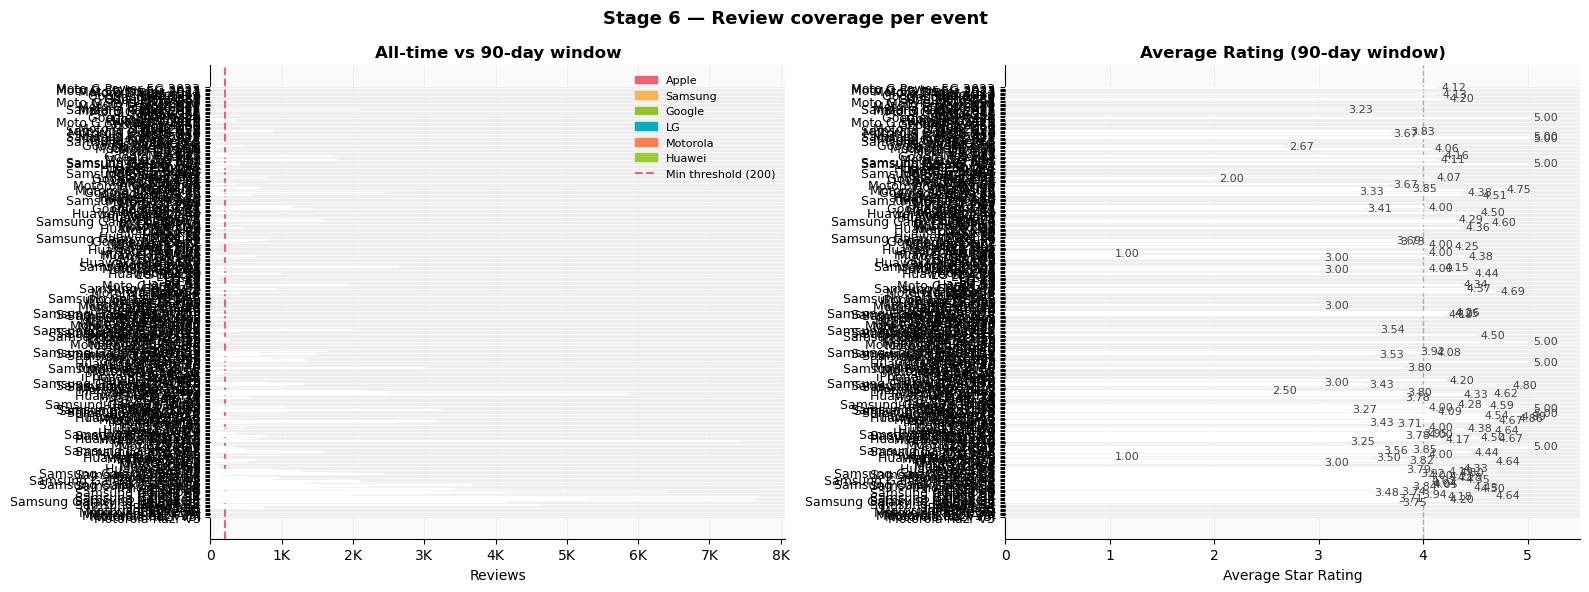

In [20]:
# Stage 6 coverage plot
if not summary_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Stage 6 — Review coverage per event',
                 fontweight='bold', fontsize=13)
    order      = summary_df.sort_values(['type','launch']).reset_index(drop=True)
    bar_colors = [BRAND_COLOR[r['brand']] for _, r in order.iterrows()]
    lt_colors  = [BRAND_LIGHT[r['brand']] for _, r in order.iterrows()]
    y          = np.arange(len(order))

    ax = axes[0]
    ax.barh(y, order['alltime'], color=lt_colors,
            edgecolor='white', height=0.6, label='All-time', zorder=3)
    ax.barh(y, order['n90'], color=bar_colors,
            edgecolor='white', height=0.6, label='90-day window', zorder=4)
    ax.axvline(THRESHOLD, color=MED_PINK, linestyle='--', linewidth=1.5)
    ax.set_yticks(y)
    ax.set_yticklabels(order['model'], fontsize=9)
    ax.set_xlabel('Reviews')
    ax.set_title('All-time vs 90-day window', fontweight='bold')
    ax.xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x,_: f'{int(x/1e3)}K' if x>=1000 else int(x)))
    patches = [mpatches.Patch(color=BRAND_COLOR[b], label=b)
               for b in BRAND_COLOR if b in set(order['brand'])]
    patches += [plt.Line2D([0],[0], color=MED_PINK, linestyle='--',
                            label=f'Min threshold ({THRESHOLD})')]
    ax.legend(handles=patches, frameon=False, fontsize=8)

    ax = axes[1]
    ax.barh(y, order['avg_rating'].fillna(0), color=bar_colors,
            edgecolor='white', height=0.6, zorder=3)
    ax.set_yticks(y)
    ax.set_yticklabels(order['model'], fontsize=9)
    ax.set_xlabel('Average Star Rating')
    ax.set_title('Average Rating (90-day window)', fontweight='bold')
    ax.set_xlim(0, 5.5)
    ax.axvline(4.0, color='#aaa', linewidth=1, linestyle='--')
    for i, (_, row) in enumerate(order.iterrows()):
        v = row['avg_rating']
        if v == v:   # not NaN
            ax.text(v+0.05, i, f'{v:.2f}', va='center', fontsize=8, color='#444')

    plt.tight_layout()
    plt.savefig('stage6_coverage.png', dpi=150, bbox_inches='tight')
    plt.show()


## Stage 7 — EDA

In [21]:
INCLUDE_MARGINAL = True
valid_events     = set(inc['model'])
if INCLUDE_MARGINAL:
    valid_events |= set(mar['model'])
phones_thesis = reviews_90d[reviews_90d['model'].isin(valid_events)].copy()
phones_thesis['window_days'] = WINDOW_DAYS
print(f'phones_thesis: {phones_thesis.shape}')
print(f'Events: {sorted(phones_thesis["model"].unique())}')


phones_thesis: (3887, 13)
Events: ['Google Pixel 3a', 'Google Pixel 4 XL', 'Google Pixel 4a', 'LG G3', 'Moto G 3rd Gen', 'Moto G 4th Gen', 'Moto G Fast', 'Moto G Power 2022', 'Samsung Galaxy S20 FE', 'Samsung Galaxy S21 Ultra', 'Samsung Galaxy S22 Ultra', 'Samsung Galaxy S23', 'Samsung Galaxy S4', 'Samsung Galaxy S5', 'Samsung Galaxy S6', 'Samsung Galaxy S7 Edge', 'Samsung Galaxy S8']


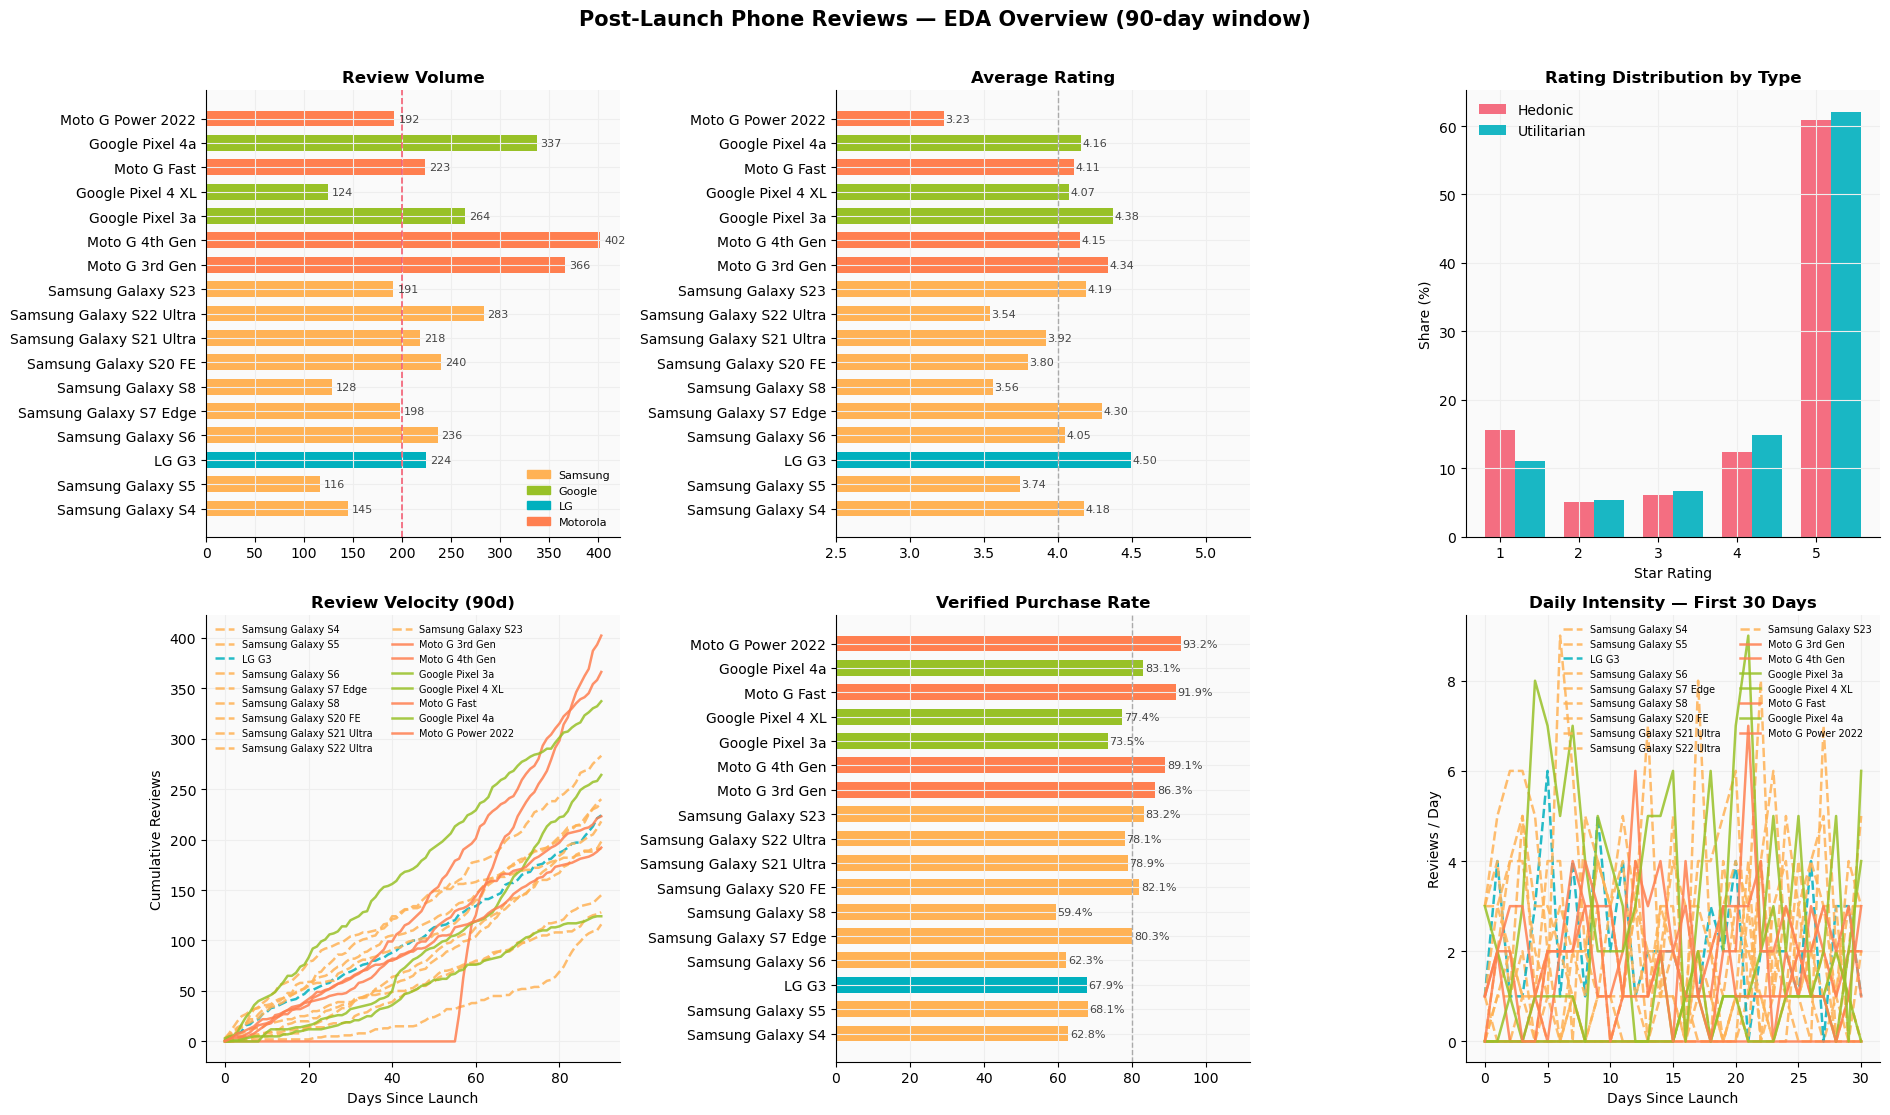

In [22]:
if not phones_thesis.empty:
    MODEL_ORDER = sorted(
        phones_thesis['model'].unique(),
        key=lambda m: (PHONE_EVENTS[m]['type'], PHONE_EVENTS[m]['launch'])
    )
    bcols = [BRAND_COLOR[PHONE_EVENTS[m]['brand']] for m in MODEL_ORDER]

    fig, axes = plt.subplots(2, 3, figsize=(19, 11))
    fig.suptitle('Post-Launch Phone Reviews — EDA Overview (90-day window)',
                 fontsize=15, fontweight='bold', y=1.01)

    # 1. Volume
    ax  = axes[0,0]
    cnt = [len(phones_thesis[phones_thesis['model']==m]) for m in MODEL_ORDER]
    b   = ax.barh(MODEL_ORDER, cnt, color=bcols, edgecolor='none', height=0.65)
    for bar, v in zip(b, cnt):
        ax.text(v+max(cnt)*0.01, bar.get_y()+bar.get_height()/2,
                f'{v:,}', va='center', fontsize=8, color='#444')
    ax.xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x,_: f'{int(x/1e3)}K' if x>=1000 else int(x)))
    ax.axvline(THRESHOLD, color=MED_PINK, linestyle='--', linewidth=1.2)
    ax.set_title('Review Volume', fontweight='bold')
    ax.legend(handles=[mpatches.Patch(color=BRAND_COLOR[b], label=b)
                       for b in BRAND_COLOR
                       if b in {PHONE_EVENTS[m]['brand'] for m in MODEL_ORDER}],
              frameon=False, fontsize=8)

    # 2. Average rating
    ax   = axes[0,1]
    avgs = [phones_thesis[phones_thesis['model']==m]['rating'].mean() for m in MODEL_ORDER]
    b    = ax.barh(MODEL_ORDER, avgs, color=bcols, edgecolor='none', height=0.65)
    for bar, v in zip(b, avgs):
        ax.text(v+0.01, bar.get_y()+bar.get_height()/2,
                f'{v:.2f}', va='center', fontsize=8, color='#444')
    ax.set_xlim(2.5, 5.3)
    ax.axvline(4.0, color='#aaa', linewidth=1, linestyle='--')
    ax.set_title('Average Rating', fontweight='bold')

    # 3. Rating distribution by type
    ax = axes[0,2]
    for i, (ptype, color) in enumerate(TYPE_COLOR.items()):
        grp = phones_thesis[phones_thesis['type']==ptype]
        if grp.empty: continue
        vc  = grp['rating'].value_counts().sort_index()
        pct = vc / vc.sum() * 100
        ax.bar([r+i*0.38 for r in pct.index], pct.values, width=0.38,
               color=color, edgecolor='none', alpha=0.9, label=ptype.capitalize())
    ax.set_xlabel('Star Rating'); ax.set_ylabel('Share (%)')
    ax.set_title('Rating Distribution by Type', fontweight='bold')
    ax.set_xticks([1,2,3,4,5]); ax.legend(frameon=False)

    # 4. Cumulative velocity
    ax = axes[1,0]
    for model, color in zip(MODEL_ORDER, bcols):
        grp   = phones_thesis[phones_thesis['model']==model]
        daily = grp.groupby('days_since_launch').size()
        cumul = daily.reindex(range(WINDOW_DAYS+1), fill_value=0).cumsum()
        ls    = '--' if PHONE_EVENTS[model]['type']=='hedonic' else '-'
        ax.plot(cumul.index, cumul.values, color=color,
                linewidth=1.8, linestyle=ls, label=model, alpha=0.85)
    ax.set_xlabel('Days Since Launch'); ax.set_ylabel('Cumulative Reviews')
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x,_: f'{int(x/1e3)}K' if x>=1000 else int(x)))
    ax.set_title(f'Review Velocity ({WINDOW_DAYS}d)', fontweight='bold')
    ax.legend(frameon=False, fontsize=7, ncol=2)

    # 5. Verified purchase rate
    ax   = axes[1,1]
    vpct = [phones_thesis[phones_thesis['model']==m]['verified_purchase'].mean()*100
            for m in MODEL_ORDER]
    b    = ax.barh(MODEL_ORDER, vpct, color=bcols, edgecolor='none', height=0.65)
    for bar, v in zip(b, vpct):
        ax.text(v+0.5, bar.get_y()+bar.get_height()/2,
                f'{v:.1f}%', va='center', fontsize=8, color='#444')
    ax.axvline(80, color='#aaa', linewidth=1, linestyle='--')
    ax.set_xlim(0, 112)
    ax.set_title('Verified Purchase Rate', fontweight='bold')

    # 6. First 30-day intensity
    ax = axes[1,2]
    for model, color in zip(MODEL_ORDER, bcols):
        grp   = phones_thesis[phones_thesis['model']==model]
        daily = (grp[grp['days_since_launch']<=30]
                 .groupby('days_since_launch').size()
                 .reindex(range(31), fill_value=0))
        ls    = '--' if PHONE_EVENTS[model]['type']=='hedonic' else '-'
        ax.plot(daily.index, daily.values, color=color,
                linewidth=1.8, linestyle=ls, label=model, alpha=0.85)
    ax.set_xlabel('Days Since Launch'); ax.set_ylabel('Reviews / Day')
    ax.set_title('Daily Intensity — First 30 Days', fontweight='bold')
    ax.legend(frameon=False, fontsize=7, ncol=2)

    plt.tight_layout()
    plt.savefig('phones_eda_overview.png', dpi=150, bbox_inches='tight')
    plt.show()


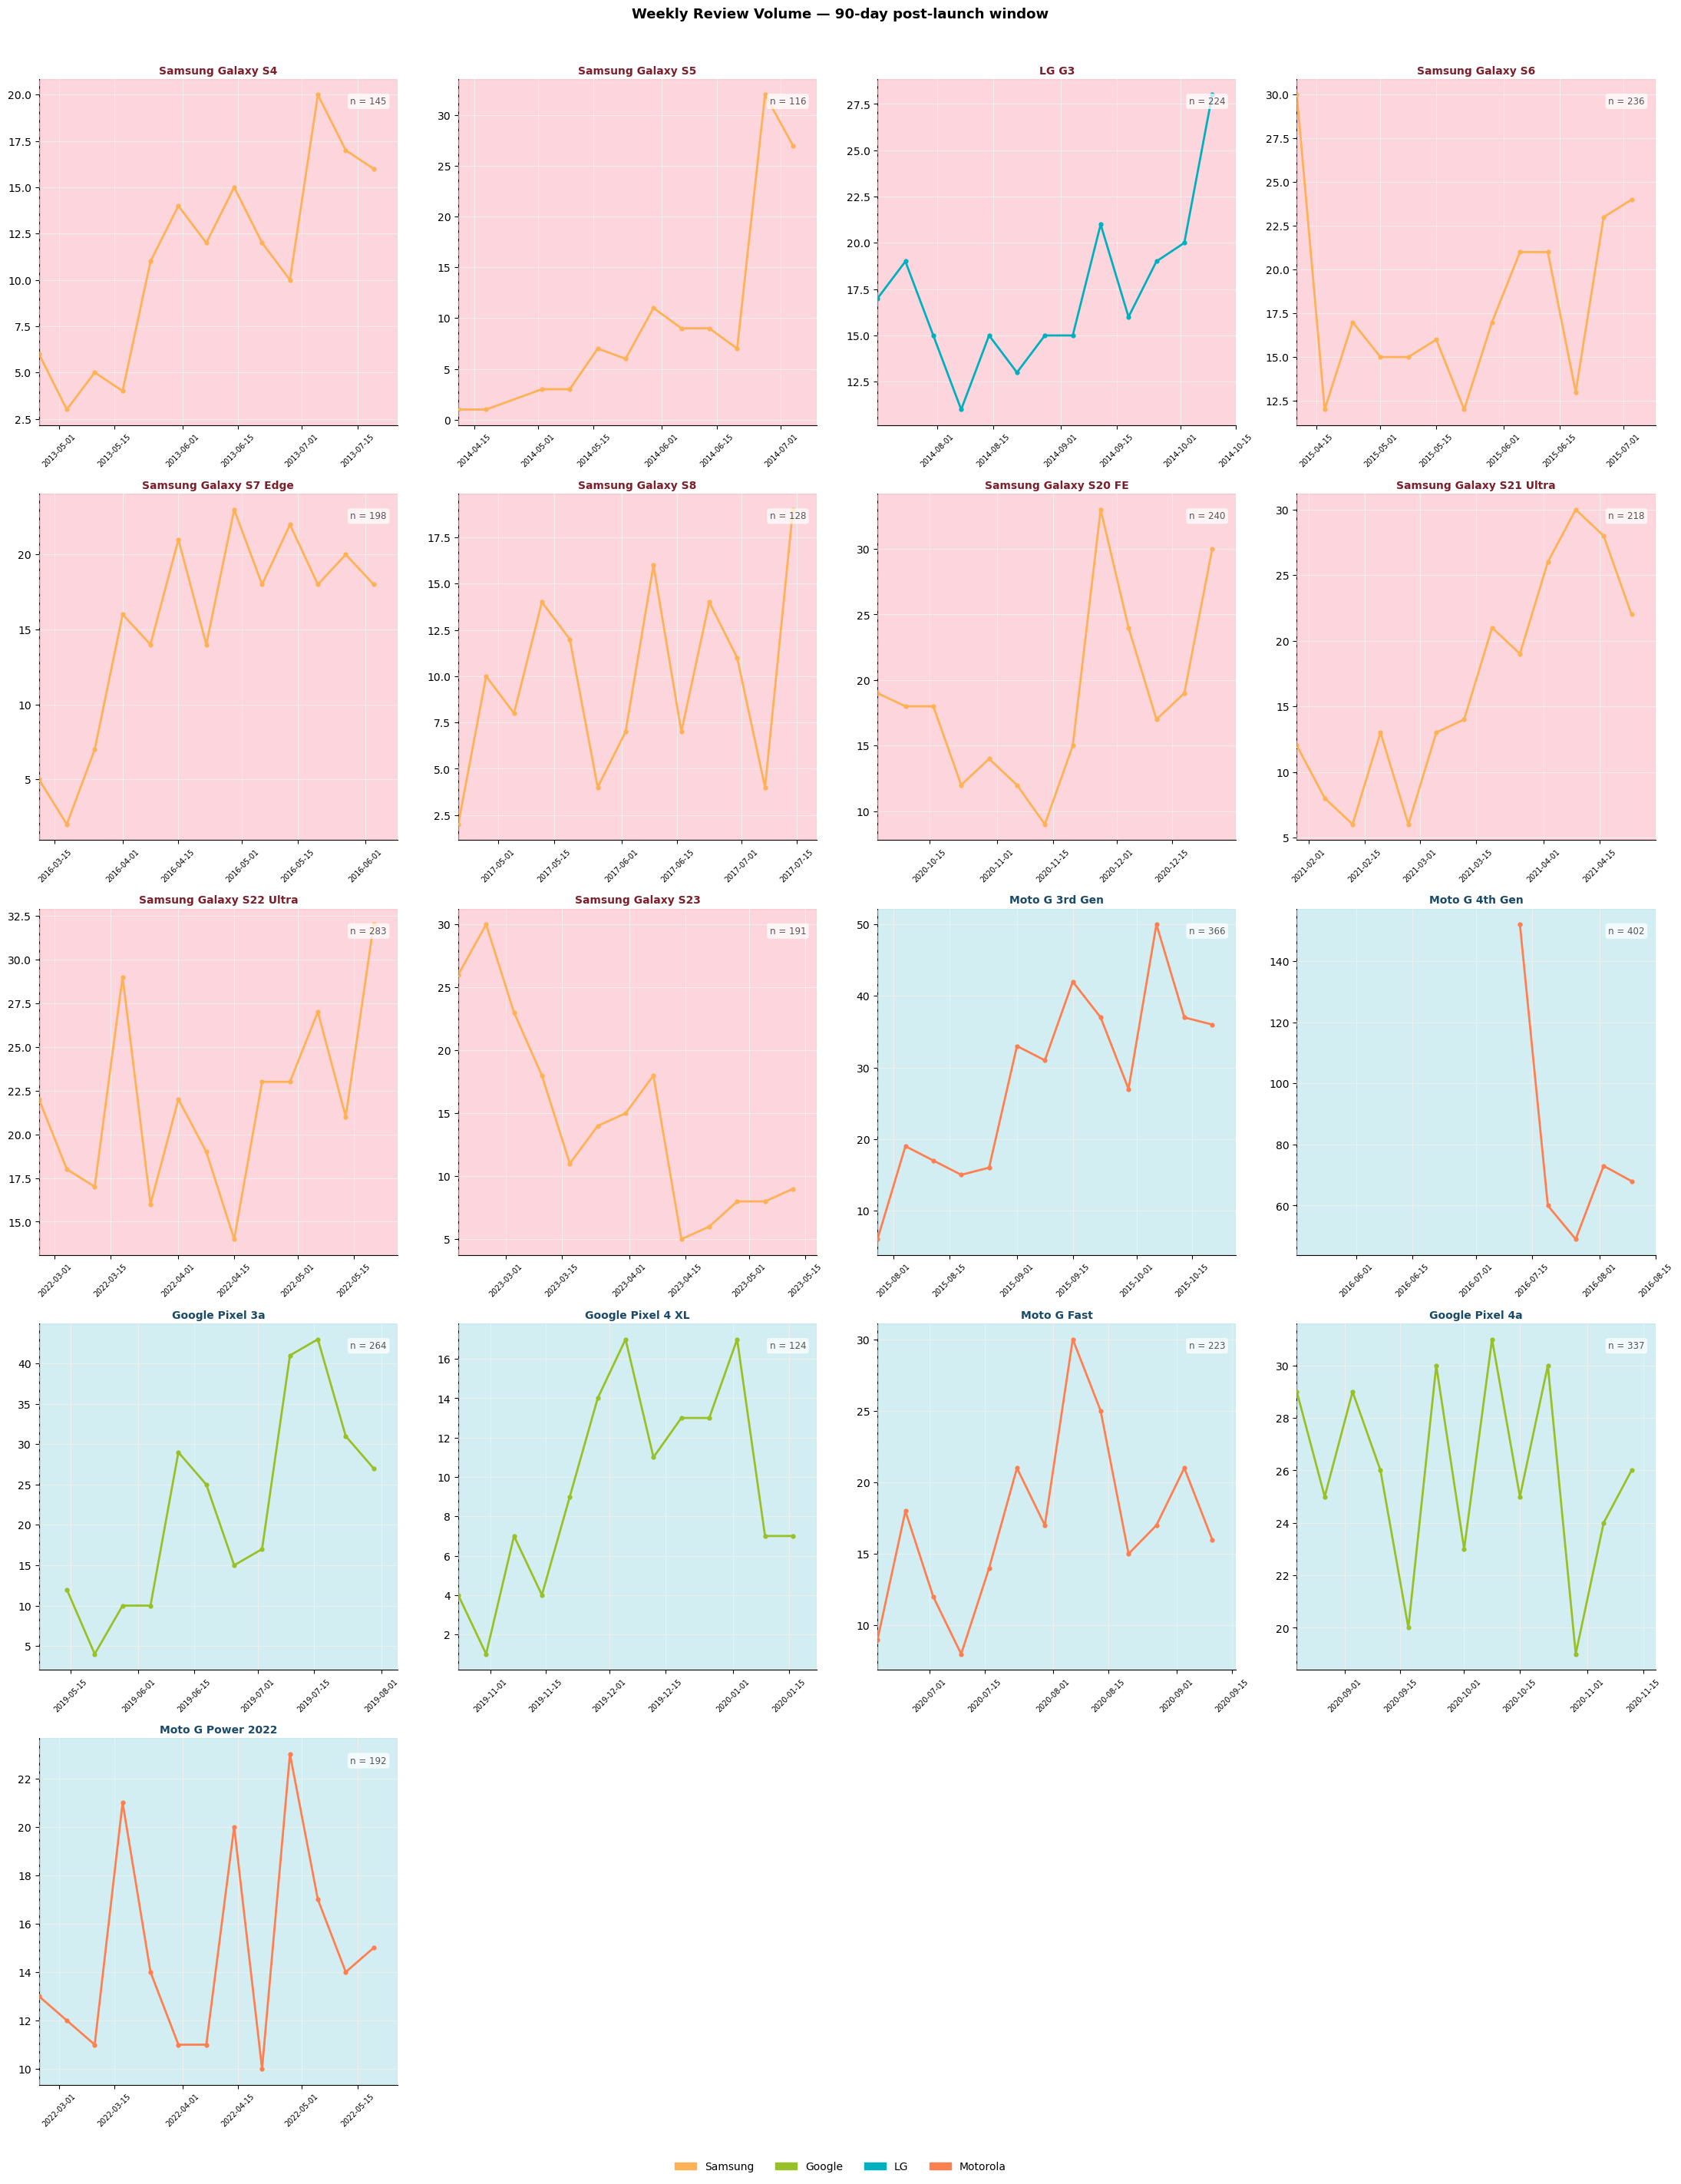

In [23]:
if not phones_thesis.empty:
    ncols = 4
    nrows = int(np.ceil(len(MODEL_ORDER) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(22, 5.5*nrows))
    fig.suptitle('Weekly Review Volume — 90-day post-launch window',
                 fontsize=13, fontweight='bold', y=1.01)
    flat = axes.flatten() if len(MODEL_ORDER) > 1 else [axes]

    for idx, model in enumerate(MODEL_ORDER):
        ax     = flat[idx]
        meta   = PHONE_EVENTS[model]
        launch = pd.Timestamp(meta['launch'])
        w_end  = launch + pd.Timedelta(days=WINDOW_DAYS)
        color  = BRAND_COLOR[meta['brand']]
        ptype  = meta['type']
        grp    = phones_thesis[phones_thesis['model']==model].copy()
        grp['week']    = grp['days_since_launch'] // 7
        wkly           = grp.groupby('week').size().reset_index(name='reviews')
        wkly['wk_ts']  = launch + pd.to_timedelta(wkly['week']*7, unit='D')
        ax.set_facecolor(TYPE_BG[ptype])
        ax.axvspan(launch, w_end, color=TYPE_LIGHT[ptype], alpha=0.30, zorder=0)
        ax.plot(wkly['wk_ts'], wkly['reviews'], color=color,
                linewidth=2.0, marker='o', markersize=3.5, zorder=3)
        ax.axvline(launch, color=MED_PINK, linewidth=1.5, linestyle='--', zorder=4)
        ax.set_xlim(launch, w_end)
        ax.set_title(model, fontweight='bold', fontsize=10,
                     color=TYPE_TITLE[ptype], pad=5)
        ax.tick_params(axis='x', labelsize=7, rotation=45)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.annotate(f'n = {len(grp):,}', xy=(0.97,0.95), xycoords='axes fraction',
                    ha='right', va='top', fontsize=8.5, color='#555',
                    bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.75, ec='none'))
    for i in range(len(MODEL_ORDER), len(flat)):
        flat[i].set_visible(False)
    fig.legend(
        handles=[mpatches.Patch(color=BRAND_COLOR[b], label=b)
                 for b in BRAND_COLOR
                 if b in {PHONE_EVENTS[m]['brand'] for m in MODEL_ORDER}],
        loc='lower center', ncol=4, frameon=False,
        fontsize=10, bbox_to_anchor=(0.5, -0.02)
    )
    plt.tight_layout()
    plt.savefig('phones_weekly_volume.png', dpi=150, bbox_inches='tight')
    plt.show()


## Stage 8 — Export

In [24]:
import sys, subprocess
subprocess.check_call([sys.executable, '-m', 'pip', 'install',
                       'google-cloud-storage', 'google-cloud-bigquery'])


0

In [25]:
import os, glob

# Check common download locations
search_paths = [
    r'C:\Users\User\Downloads\*.json',
    r'C:\Users\User\Desktop\*.json',
    r'C:\Users\User\.gcp\*.json',
    r'C:\Users\User\Documents\*.json',
]

for pattern in search_paths:
    matches = glob.glob(pattern)
    if matches:
        for m in matches:
            print(m)

C:\Users\User\Downloads\app_store_collection_results.json
C:\Users\User\Downloads\content_website_seo_collection_results.json
C:\Users\User\Downloads\email_marketing_collection_results.json
C:\Users\User\Downloads\events_collection_results.json
C:\Users\User\Downloads\facebook_ads_collection_results.json
C:\Users\User\Downloads\google_ads_collection_results.json
C:\Users\User\Downloads\import_results.json
C:\Users\User\Downloads\journey_assembly_results.json
C:\Users\User\Downloads\linkedin_ads_collection_results.json
C:\Users\User\Downloads\organic_social_collection_results.json
C:\Users\User\Downloads\sf_auth.json
C:\Users\User\.gcp\thesis-sa-key.json


In [26]:
import google.auth
from google.cloud import storage, bigquery
import io
import pandas as pd

PROJECT_ID = 'vuthesis-llm-buzz'
BUCKET     = 'thesis-bucket-vua'
BQ_DATASET = 'thesis_data'
BQ_TABLE   = 'phones_reviews'
GCS_BLOB   = 'amazon_reviews/phones_thesis.parquet'

# No key file needed, uses gcloud login
creds, _   = google.auth.default(
    scopes=['https://www.googleapis.com/auth/cloud-platform']
)

# Quick check creds loaded
print(f'Credentials type : {type(creds).__name__}')
print(f'Project          : {PROJECT_ID}')


#  Sanity check 
expected = {'rating','text','asin','parent_asin','timestamp','helpful_vote',
            'verified_purchase','model','type','brand','launch',
            'days_since_launch','window_days'}
missing  = expected - set(phones_thesis.columns)
print(f'Missing columns : {missing or "none"}')
print(f'Shape           : {phones_thesis.shape}')
if not phones_thesis.empty:
    print(f'Date range      : {phones_thesis["timestamp"].min().date()} -> '
          f'{phones_thesis["timestamp"].max().date()}')

#  Step 1: Upload parquet to GCS 
print('\nUploading to GCS...')
buffer     = io.BytesIO()
phones_thesis.to_parquet(buffer, index=False)
buffer.seek(0)

gcs_client = storage.Client(project=PROJECT_ID, credentials=creds)
bucket_obj = gcs_client.bucket(BUCKET)
blob       = bucket_obj.blob(GCS_BLOB)
blob.upload_from_file(buffer, content_type='application/octet-stream')

gcs_uri = f'gs://{BUCKET}/{GCS_BLOB}'
print(f'Uploaded  : {gcs_uri}')
print(f'Size      : {blob.size / 1e6:.1f} MB')

# Step 2: Load from GCS into BigQuery 
print('\nLoading into BigQuery...')
bq_client  = bigquery.Client(project=PROJECT_ID, credentials=creds)
table_ref  = f'{PROJECT_ID}.{BQ_DATASET}.{BQ_TABLE}'

job_config = bigquery.LoadJobConfig(
    source_format       = bigquery.SourceFormat.PARQUET,
    write_disposition   = bigquery.WriteDisposition.WRITE_TRUNCATE,  # overwrite on re-run
    autodetect          = True,
)

load_job = bq_client.load_table_from_uri(gcs_uri, table_ref, job_config=job_config)
load_job.result()   # blocks until complete

table    = bq_client.get_table(table_ref)
print(f'BigQuery table : {table_ref}')
print(f'Rows loaded    : {table.num_rows:,}')
print(f'Schema         : {[f.name for f in table.schema]}')

# Step 3: Smoke test — pull row counts back from BQ 
query = f"""
    SELECT model, type, COUNT(*) AS n_reviews, ROUND(AVG(rating), 2) AS avg_rating
    FROM `{table_ref}`
    GROUP BY model, type
    ORDER BY n_reviews DESC
"""
result = bq_client.query(query).to_dataframe()
print('\nBigQuery smoke test:')
print(result.to_string(index=False))

Credentials type : Credentials
Project          : vuthesis-llm-buzz
Missing columns : none
Shape           : (3887, 13)
Date range      : 2013-04-27 -> 2023-05-18

Uploading to GCS...
Uploaded  : gs://thesis-bucket-vua/amazon_reviews/phones_thesis.parquet
Size      : 1.4 MB

Loading into BigQuery...
BigQuery table : vuthesis-llm-buzz.thesis_data.phones_reviews
Rows loaded    : 3,887
Schema         : ['rating', 'text', 'asin', 'parent_asin', 'timestamp', 'helpful_vote', 'verified_purchase', 'model', 'type', 'brand', 'launch', 'days_since_launch', 'window_days']

BigQuery smoke test:
                   model        type  n_reviews  avg_rating
          Moto G 4th Gen utilitarian        402        4.15
          Moto G 3rd Gen utilitarian        366        4.34
         Google Pixel 4a utilitarian        337        4.16
Samsung Galaxy S22 Ultra     hedonic        283        3.54
         Google Pixel 3a utilitarian        264        4.38
   Samsung Galaxy S20 FE     hedonic        240    

c:\Users\User\anaconda3\Lib\site-packages\google\cloud\bigquery\table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(
